# Predicting Employee Attrition and Identifying Flight Risk Factors

**Group Members:** Shania Siew (816039282), Terrence Murray (816038951), Tyler Baksh (816039328), Syam Manchikanti (816041877)

## Introduction

Employee attrition is expensive. When someone leaves unexpectedly, the company deals with disrupted operations, lost productivity, and recruitment costs that can run anywhere from 50% to 200% of that person's annual salary. Despite this, most organizations still handle turnover reactively, scrambling to fill roles after people have already walked out the door.

This project builds a workforce intelligence platform that flips that approach. We use machine learning classifiers and survival analysis to predict which employees are likely to leave and roughly when, giving organizations a 3 to 6 month window to step in. We also dig into the factors behind flight risk (overtime, tenure, job satisfaction, pay) and check whether our models treat employees fairly across protected attributes like gender, age, marital status, and education field.

We work primarily with the **IBM HR Analytics Employee Attrition & Performance** dataset, which contains detailed employee records covering tenure, salary, role, performance ratings, and attrition status. It's well suited for both classification and survival analysis. We supplement it with the **HR Analytics Job Change of Data Scientists** dataset for additional context on workforce mobility and career transitions.

Our deliverables include a predictive attrition model with flight risk tiers, feature importance analysis (Random Forest, LASSO, SHAP) to surface the main attrition drivers, fairness audits across demographic subgroups, an ROI calculator for estimating cost savings from targeted retention efforts, and an interactive dashboard showing survival curves, risk profiles, and department-level attrition trends.

### Domain Context: Flight Risk Indicators and Data Considerations

Workforce analytics research points to several behavioral and organizational signals tied to flight risk: declining productivity, lower motivation, more absences, reluctance to take on new projects, and pulling back from professional development (AIHR, 2024). Mondore (cited by SHRM) suggests that predictive attrition models should draw on demographic data (age, gender, marital status, education, tenure), performance reviews, engagement surveys, workload metrics, PTO and absenteeism records, and compensation data. He emphasizes including compensation so leadership can put a dollar figure on what's at stake if turnover isn't addressed.

**What the IBM dataset covers:**

| Recommended Data Category | Available Features |
|---|---|
| Demographics & tenure | `Age`, `Gender`, `MaritalStatus`, `Education`, `YearsAtCompany`, `DistanceFromHome` |
| Performance metrics | `PerformanceRating` |
| Engagement & satisfaction | `JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance`, `JobInvolvement` |
| Workload proxies | `OverTime` |
| Compensation & career growth | `MonthlyIncome`, `PercentSalaryHike`, `StockOptionLevel`, `YearsSinceLastPromotion`, `JobLevel` |
| Career mobility | `NumCompaniesWorked`, `TotalWorkingYears`, `TrainingTimesLastYear`, `YearsInCurrentRole` |

**Limitations:** time-series engagement survey data, PTO/absenteeism records, exit survey responses, and granular productivity metrics. These gaps are a known limitation of working with this dataset.

*Sources: [AIHR — Flight Risk Employee](https://www.aihr.com/blog/flight-risk-employee/), [SHRM — How to Identify Company's Flight Risks](https://www.shrm.org/topics-tools/news/technology/how-to-identify-companys-flight-risks)*

## Part 1: Data Exploration and Cleaning

Before we build any models, we need to get familiar with our data. This section covers:

**Data Quality Checks**
- Load and inspect the dataset (schema, types, dimensions)
- Check for missing values and duplicates
- Drop constant and ID columns (`EmployeeCount`, `StandardHours`, `Over18`, `EmployeeNumber`)

**Exploratory Analysis**
- Summary statistics and distribution plots for numeric, ordinal, and categorical features
- Skewness analysis and log transforms for right-tailed features
- Outlier detection using the IQR method

**Preprocessing**
- Inspect the `Attrition` target variable for class imbalance
- Encode categorical variables (binary mapping + one-hot encoding)

### 1.1.1 Loading and Inspecting the Dataset

First, we download and load the IBM HR Analytics Employee Attrition & Performance dataset. Once it's loaded, we take a quick look at the shape, column names, and data types to get a sense of what we're working with.

In [1]:
import polars as pl
import requests
import os

# Data Directory
DATA_DIR = "data/raw"
FILE_NAME = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
os.makedirs(DATA_DIR, exist_ok=True)

# Download the dataset from source
url: str = "https://www.kaggle.com/api/v1/datasets/download/pavansubhasht/ibm-hr-analytics-attrition-dataset"

# Check if the dataset already exists
dataset_path = os.path.join(DATA_DIR, "ibm_hr_analytics_attrition_dataset.zip")
if os.path.exists(dataset_path):
    print("Dataset already exists. Skipping download.")
else:
    # Stream download the dataset
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(os.path.join(DATA_DIR, "ibm_hr_analytics_attrition_dataset.zip"), "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
    else:    print(f"Failed to download dataset. Status code: {response.status_code}")

# Unzip the dataset
import zipfile
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)

In [2]:
# Load the dataset using Polars
df = pl.read_csv(os.path.join(DATA_DIR, FILE_NAME))

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns\n")

# List all columns with their data types
for col in df.columns:
    print(f"  {col:30s} {str(df[col].dtype)}")

Dataset loaded: 1470 rows, 35 columns

  Age                            Int64
  Attrition                      String
  BusinessTravel                 String
  DailyRate                      Int64
  Department                     String
  DistanceFromHome               Int64
  Education                      Int64
  EducationField                 String
  EmployeeCount                  Int64
  EmployeeNumber                 Int64
  EnvironmentSatisfaction        Int64
  Gender                         String
  HourlyRate                     Int64
  JobInvolvement                 Int64
  JobLevel                       Int64
  JobRole                        String
  JobSatisfaction                Int64
  MaritalStatus                  String
  MonthlyIncome                  Int64
  MonthlyRate                    Int64
  NumCompaniesWorked             Int64
  Over18                         String
  OverTime                       String
  PercentSalaryHike              Int64
  PerformanceRat

### Ordinal Feature Mappings

Several numeric columns in the dataset represent ordinal categorical variables. The integer encodings correspond to the following labels:

| Column | 1 | 2 | 3 | 4 | 5 |
|--------|---|---|---|---|---|
| **Education** | Below College | College | Bachelor | Master | Doctor |
| **EnvironmentSatisfaction** | Low | Medium | High | Very High | — |
| **JobInvolvement** | Low | Medium | High | Very High | — |
| **JobSatisfaction** | Low | Medium | High | Very High | — |
| **PerformanceRating** | Low | Good | Excellent | Outstanding | — |
| **RelationshipSatisfaction** | Low | Medium | High | Very High | — |
| **WorkLifeBalance** | Bad | Good | Better | Best | — |

These fields are already numerically encoded in a meaningful ordinal order, so they can be used directly in modeling without further transformation.

### 1.1.3 Missing Value Analysis

We check every column for nulls. If any are found, we'll decide whether to impute or drop them.

In [3]:
# Count nulls per column
null_counts = df.null_count()
total_nulls = sum(null_counts.row(0))

if total_nulls == 0:
    print(f"No missing values found across all {len(df.columns)} columns.")
else:
    # Show only columns with nulls
    for col in df.columns:
        n = df[col].null_count()
        if n > 0:
            print(f"  {col}: {n} nulls ({n / len(df) * 100:.1f}%)")

No missing values found across all 35 columns.


### 1.1.4 Duplicate Detection

We check for duplicate rows and remove them if any exist.

In [4]:
# Check for and remove duplicate rows
n_before = len(df)
df = df.unique().sort("EmployeeNumber")  # sort to ensure consistent row order across runs
n_dupes = n_before - len(df)

if n_dupes == 0:
    print(f"No duplicate rows found ({n_before} rows).")
else:
    print(f"Removed {n_dupes} duplicate rows. {n_before} -> {len(df)} rows.")

No duplicate rows found (1470 rows).


### 1.1.2 Removing Irrelevant Features

Looking at the columns, `EmployeeNumber` is just a unique row ID, while `EmployeeCount`, `StandardHours`, and `Over18` are the same value for every row. None of these tell us anything useful about attrition, so we drop them.

In [5]:
drop_cols: list[str] = ["EmployeeCount", "EmployeeNumber", "StandardHours", "Over18"]

df = df.drop(drop_cols)

print(f"Dropped {len(drop_cols)} columns: {drop_cols}")
print(f"Remaining: {df.shape[0]} rows, {df.shape[1]} columns")

Dropped 4 columns: ['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18']
Remaining: 1470 rows, 31 columns


### 1.2.1 Summary Statistics

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# -- Feature groups --
# Ordinal: integer-coded but represent ranked categories (see mappings above)
ordinal_cols: list[str] = [
    "Education", "EnvironmentSatisfaction", "JobInvolvement", "JobLevel",
    "JobSatisfaction", "PerformanceRating", "RelationshipSatisfaction",
    "StockOptionLevel", "TrainingTimesLastYear", "WorkLifeBalance",
]

# Categorical: string-typed columns
categorical_cols: list[str] = [col for col in df.columns if df[col].dtype == pl.String]

# Numeric: continuous int/float columns, excluding ordinals
numeric_cols: list[str] = [
    col for col in df.columns
    if df[col].dtype in [pl.Int64, pl.Float64] and col not in ordinal_cols
]


# -- Reusable plotting helpers --
def plot_grid(cols, ncols, plot_fn, title, figsize_per_row=4):
    """Create a grid of subplots, calling plot_fn(ax, col) for each column."""
    nrows = -(-len(cols) // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * figsize_per_row))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cols):
        plot_fn(axes[i], col)

    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


print(f"Numeric features ({len(numeric_cols)}):     {numeric_cols}")
print(f"Ordinal features ({len(ordinal_cols)}):     {ordinal_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Numeric features (13):     ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Ordinal features (10):     ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance']
Categorical features (8): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


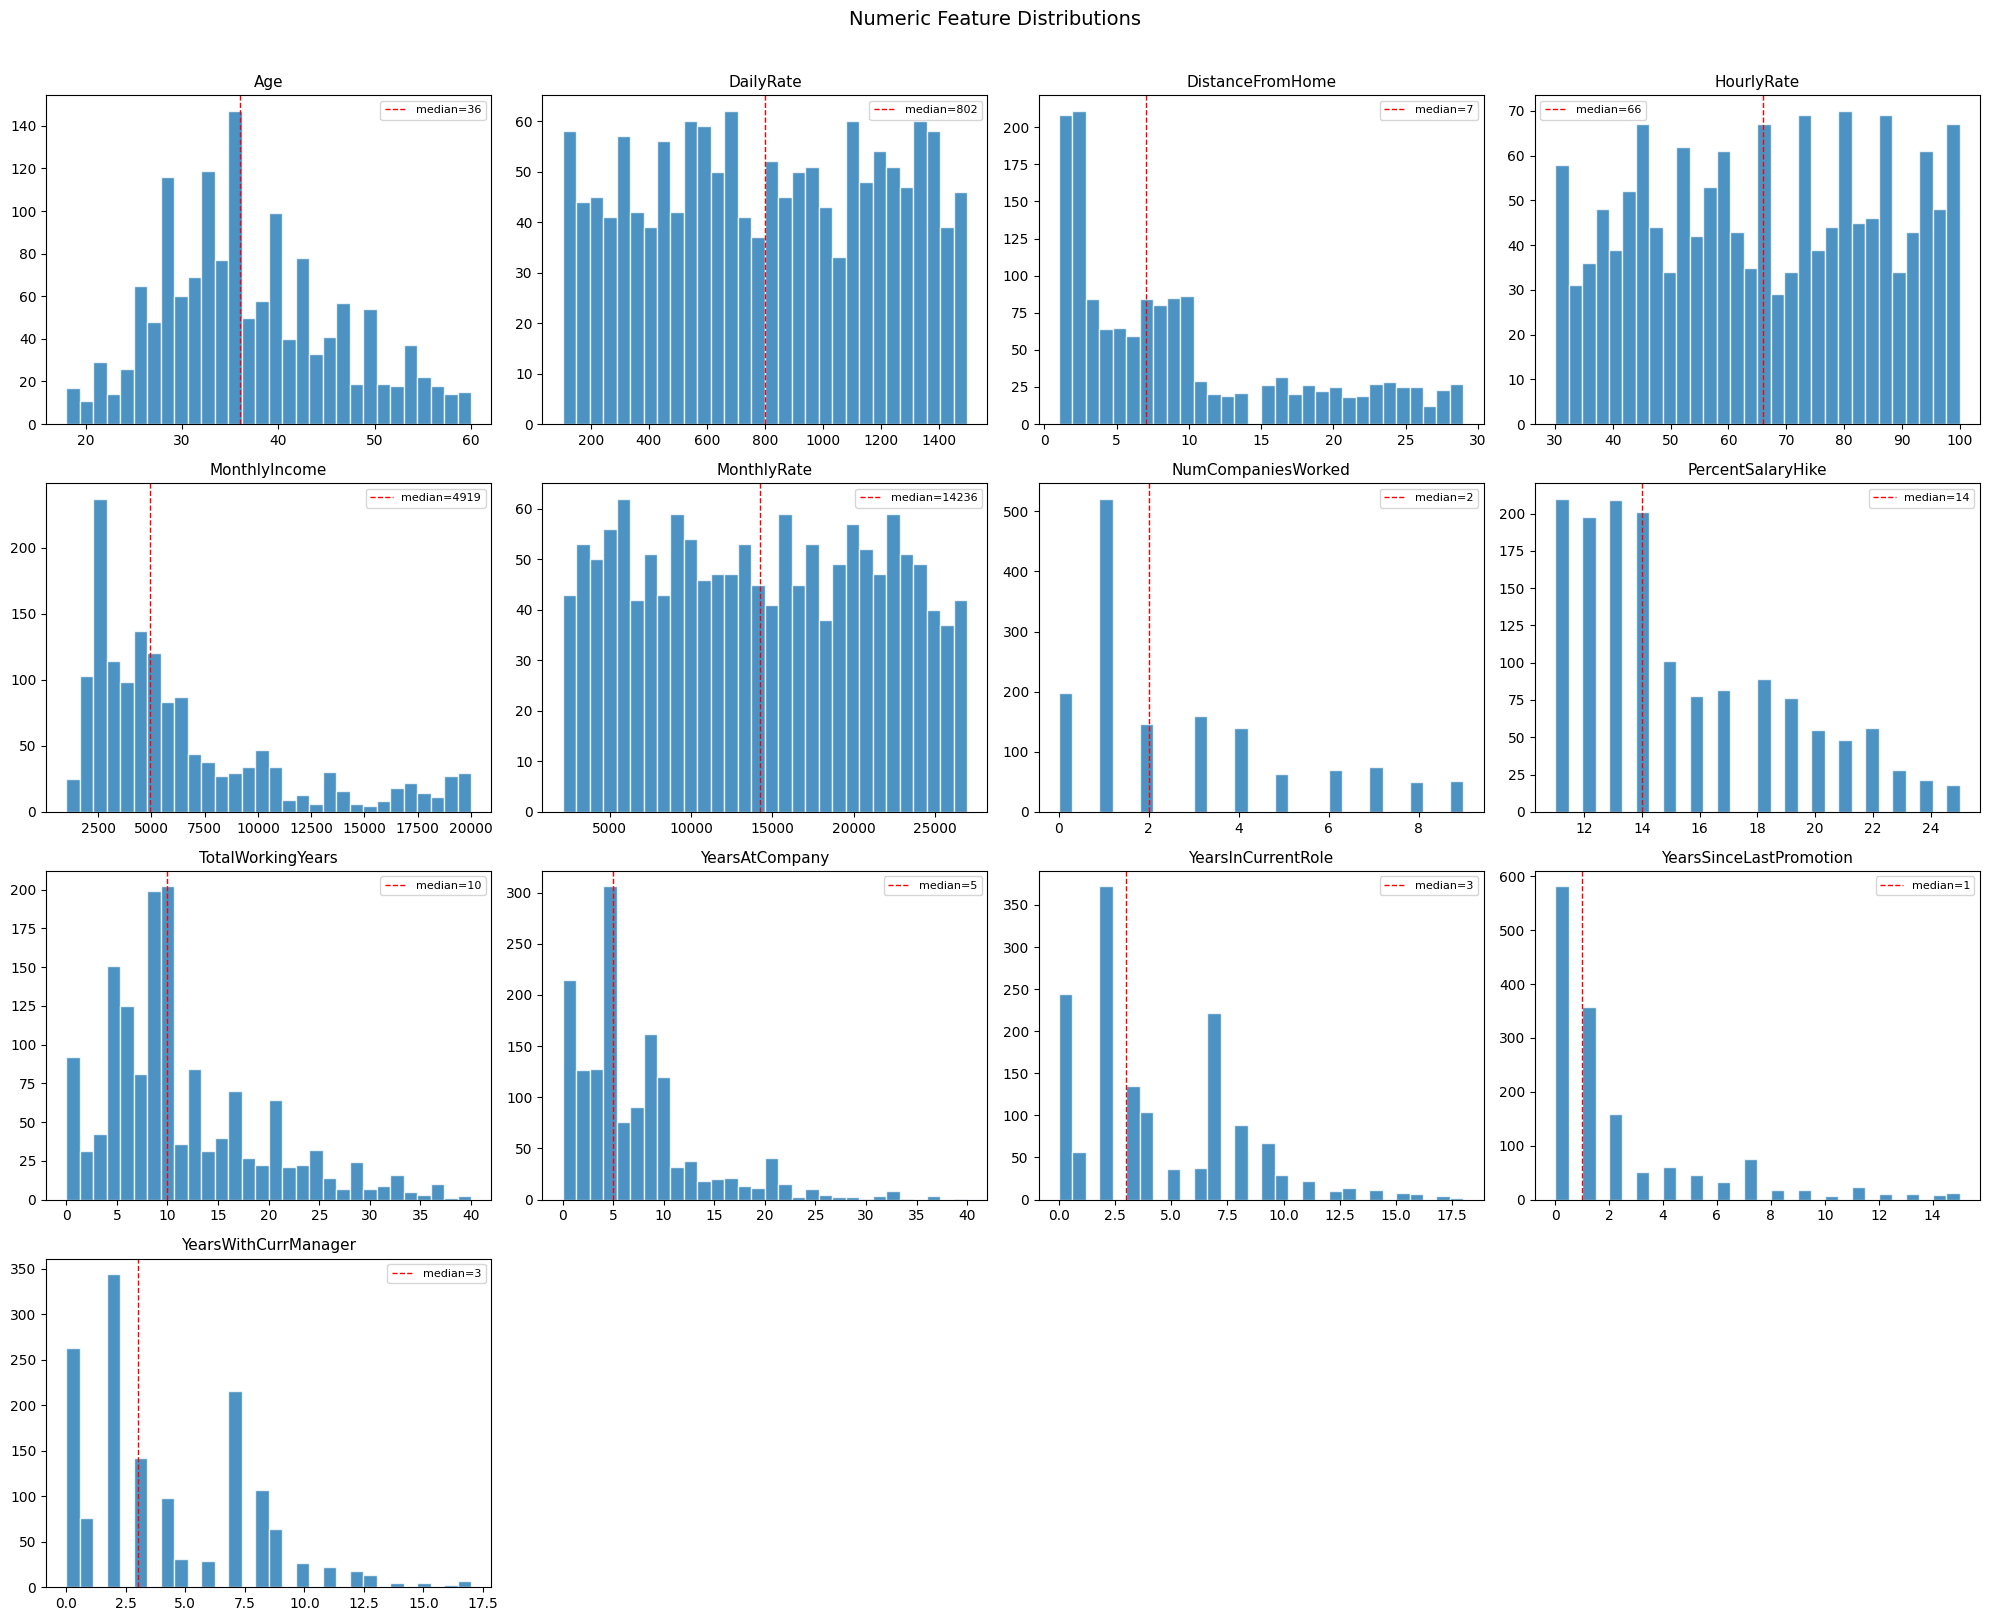

In [7]:
# Histogram + median line for each numeric feature
def plot_numeric_hist(ax, col):
    data = df.get_column(col).to_list()
    median = df.get_column(col).median()
    ax.hist(data, bins=30, edgecolor="white", alpha=0.8)
    ax.axvline(median, color="red", linestyle="--", linewidth=1, label=f"median={median:.0f}")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

plot_grid(numeric_cols, 4, plot_numeric_hist, "Numeric Feature Distributions")

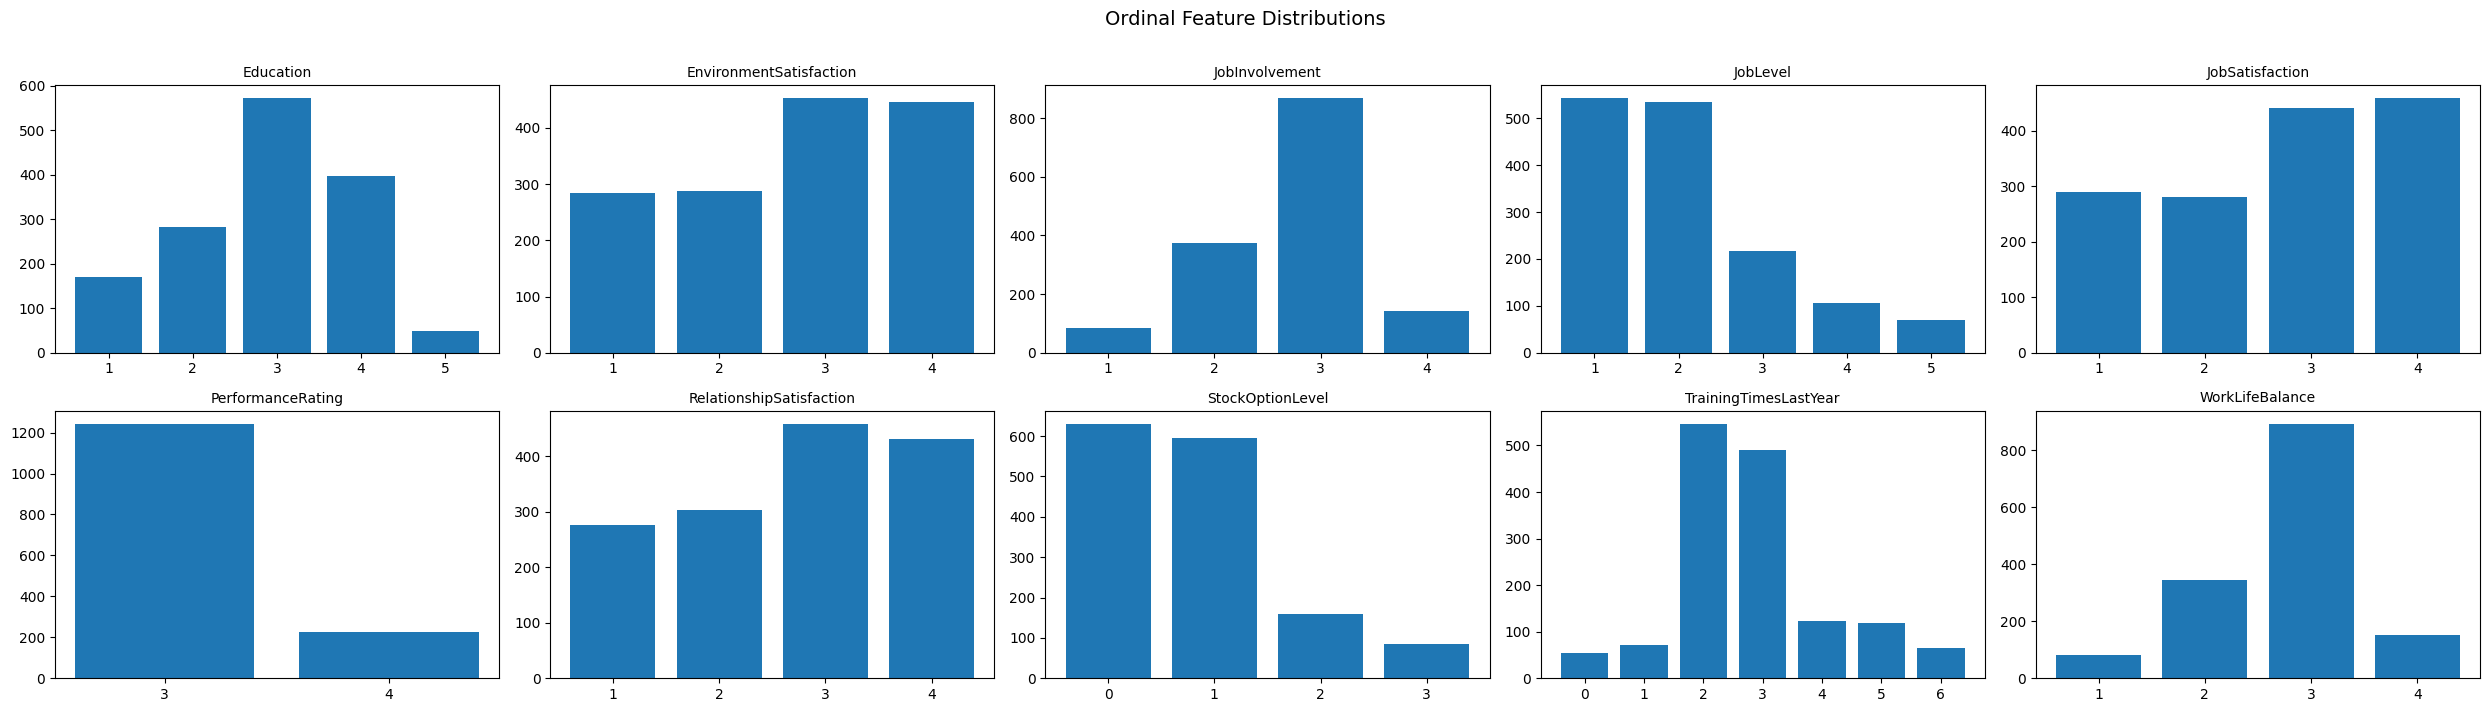

In [8]:
# Bar chart for each ordinal feature (sorted by category value)
def plot_ordinal_bar(ax, col):
    counts = df[col].value_counts().sort(col)
    ax.bar([str(v) for v in counts.get_column(col).to_list()], counts.get_column("count").to_list())
    ax.set_title(col, fontsize=10)

plot_grid(ordinal_cols, 5, plot_ordinal_bar, "Ordinal Feature Distributions", figsize_per_row=3.5)

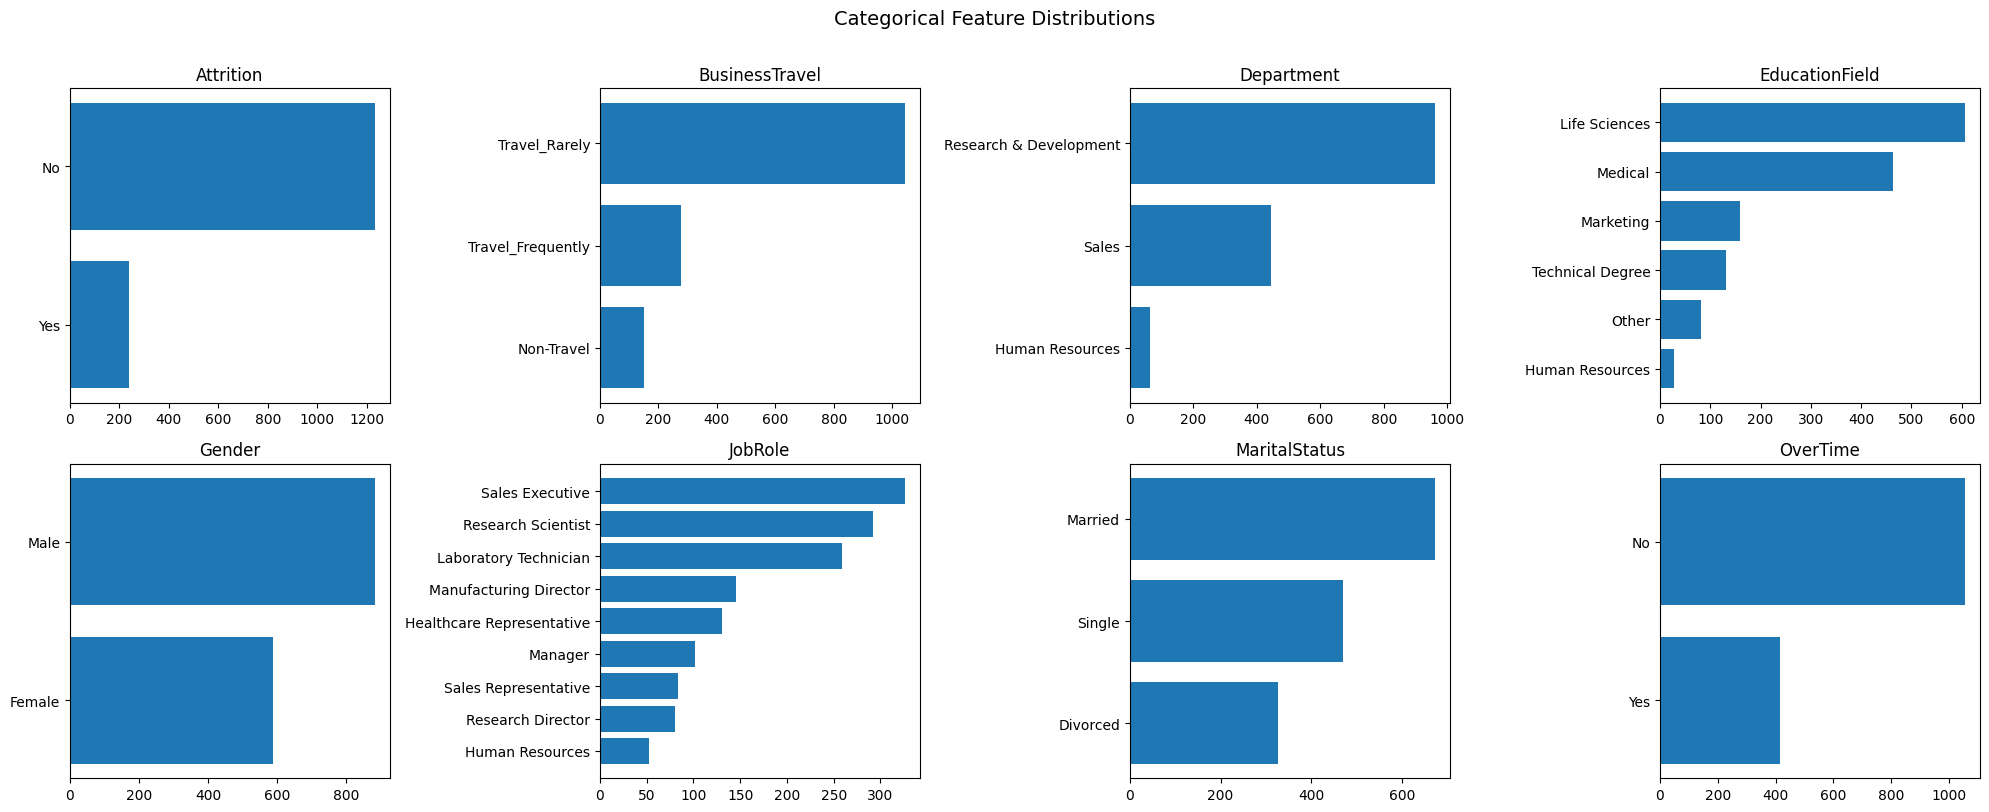

In [9]:
# Horizontal bar chart for each categorical feature (sorted by frequency)
def plot_categorical_bar(ax, col):
    counts = df[col].value_counts().sort("count", descending=True)
    ax.barh(counts.get_column(col).to_list(), counts.get_column("count").to_list())
    ax.set_title(col)
    ax.invert_yaxis()

plot_grid(categorical_cols, 4, plot_categorical_bar, "Categorical Feature Distributions")

### 1.2.2 Skewness and Outlier Assessment

A few of the numeric features are visibly right-skewed. Here we quantify the skewness and use box plots to spot outliers. As a rule of thumb, skewness beyond +/- 1 is considered significant. For outliers, we use the IQR method (points beyond 1.5x the interquartile range).

In [10]:
# Compute skewness using scipy and display sorted results
skew_records = [
    (col, round(stats.skew(df.get_column(col).to_list()), 2))
    for col in numeric_cols
]
skew_df = pl.DataFrame({"Feature": [r[0] for r in skew_records], "Skewness": [r[1] for r in skew_records]})
skew_df = skew_df.sort("Skewness", descending=True)

print("Skewness of numeric features (|skew| > 1 is notable):\n")
for feat, skew in skew_df.iter_rows():
    flag = " !!" if abs(skew) > 1 else ""
    print(f"  {feat:30s} {skew:>6.2f}{flag}")

Skewness of numeric features (|skew| > 1 is notable):

  YearsSinceLastPromotion          1.98 !!
  YearsAtCompany                   1.76 !!
  MonthlyIncome                    1.37 !!
  TotalWorkingYears                1.12 !!
  NumCompaniesWorked               1.03 !!
  DistanceFromHome                 0.96
  YearsInCurrentRole               0.92
  YearsWithCurrManager             0.83
  PercentSalaryHike                0.82
  Age                              0.41
  MonthlyRate                      0.02
  DailyRate                       -0.00
  HourlyRate                      -0.03


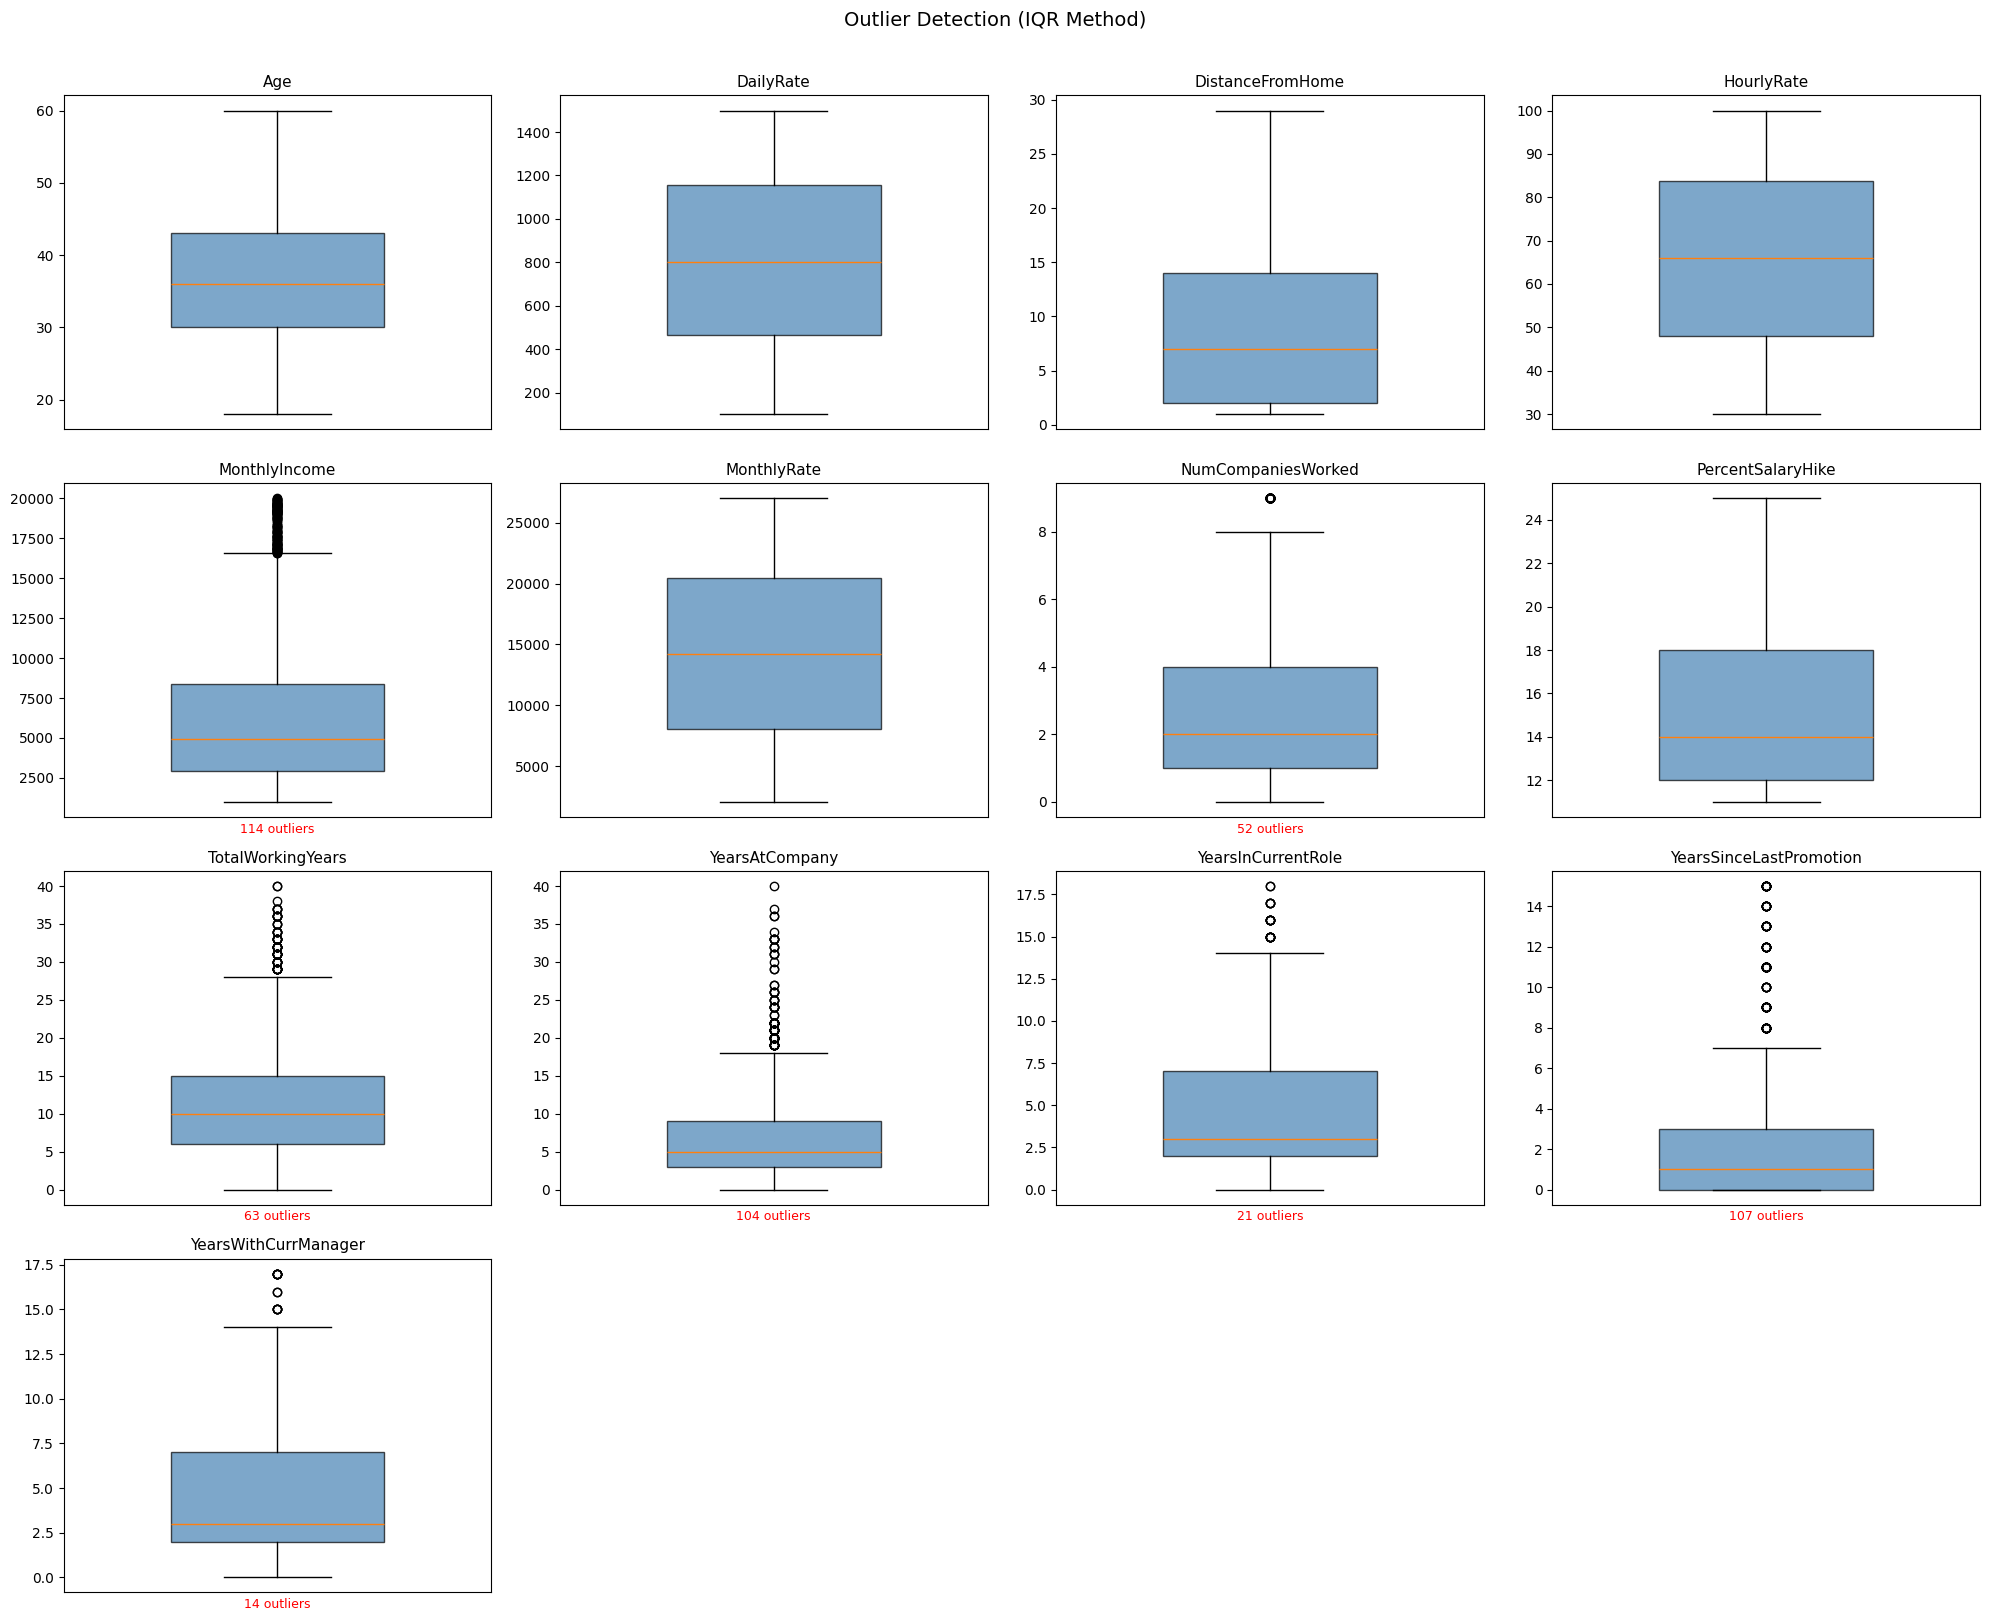

In [11]:
# Box plot + outlier count for each numeric feature
def plot_boxplot(ax, col):
    data = df.get_column(col).to_list()
    bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.5)
    bp["boxes"][0].set(facecolor="steelblue", alpha=0.7)
    ax.set_title(col, fontsize=11)
    ax.set_xticks([])

    # Count IQR outliers
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    n_outliers = sum(1 for v in data if v < q1 - 1.5 * iqr or v > q3 + 1.5 * iqr)
    if n_outliers > 0:
        ax.set_xlabel(f"{n_outliers} outliers", fontsize=9, color="red")

plot_grid(numeric_cols, 4, plot_boxplot, "Outlier Detection (IQR Method)")

### 1.2.3 Log Transform for Skewed Features

For features with skewness above 1, we apply a `log1p` transform (log(1 + x)) to pull in the right tail. We use `log1p` instead of plain `log` because some features contain zeros. This mainly benefits LASSO and other linear models; tree-based models like Random Forest won't be affected either way.

Applying log1p to 5 skewed features: ['YearsSinceLastPromotion', 'YearsAtCompany', 'MonthlyIncome', 'TotalWorkingYears', 'NumCompaniesWorked']

Added columns: ['YearsSinceLastPromotion_log', 'YearsAtCompany_log', 'MonthlyIncome_log', 'TotalWorkingYears_log', 'NumCompaniesWorked_log']
DataFrame shape: 1470 rows, 36 columns


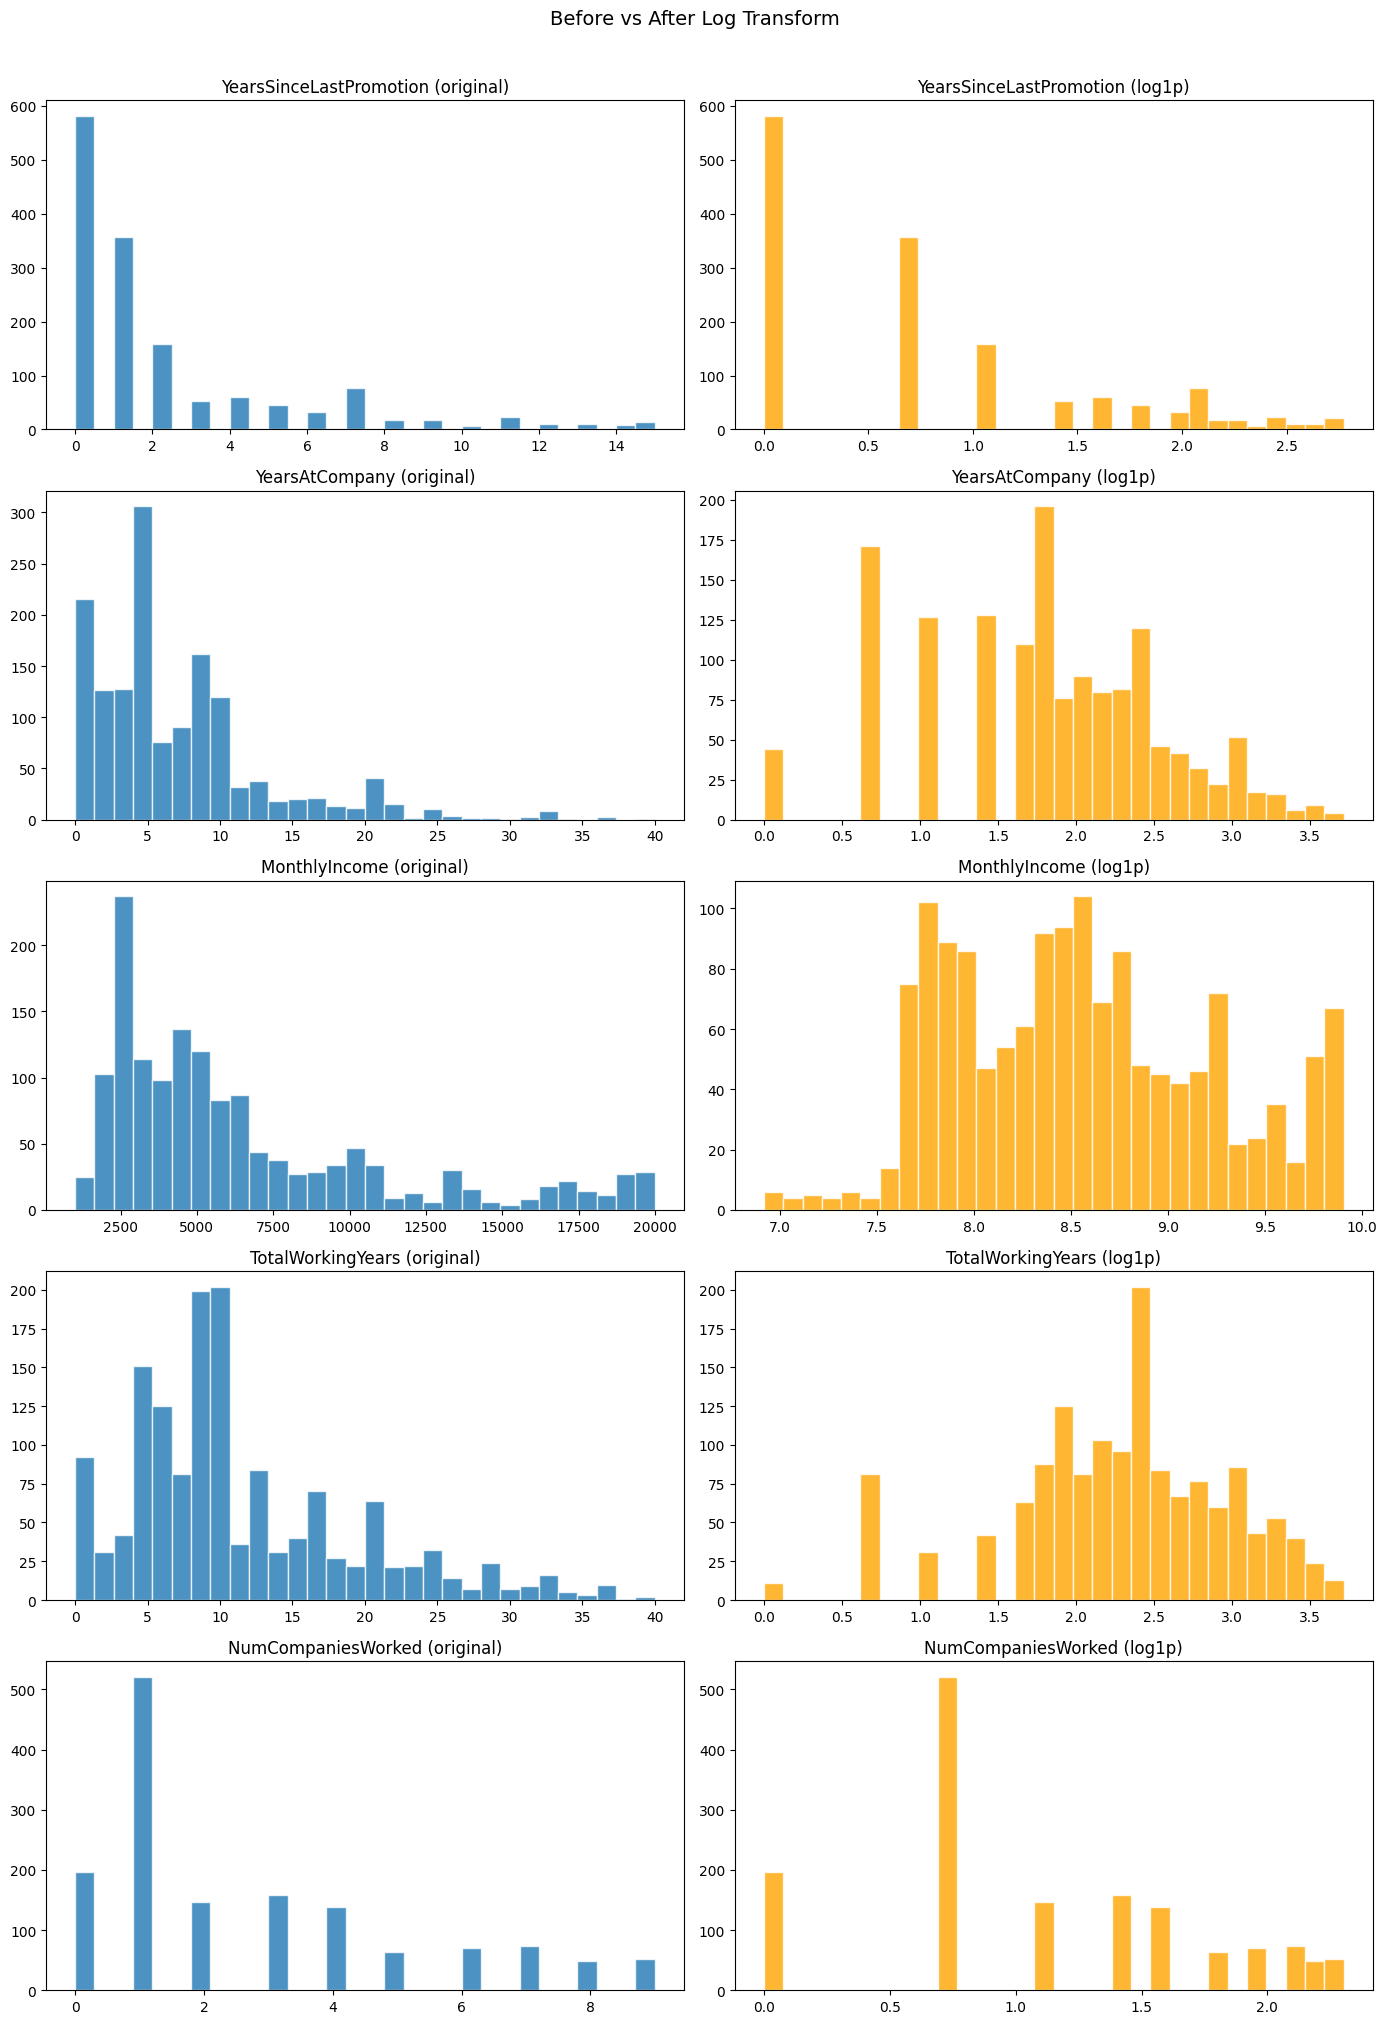

In [12]:
# Apply log1p to features with |skewness| > 1
skewed_cols = [feat for feat, skew in skew_df.iter_rows() if abs(skew) > 1]
print(f"Applying log1p to {len(skewed_cols)} skewed features: {skewed_cols}\n")

for col in skewed_cols:
    df = df.with_columns(pl.col(col).cast(pl.Float64).log1p().alias(f"{col}_log"))

print(f"Added columns: {[f'{c}_log' for c in skewed_cols]}")
print(f"DataFrame shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Side-by-side comparison: original vs transformed
fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(14, 4 * len(skewed_cols)))

for i, col in enumerate(skewed_cols):
    axes[i][0].hist(df.get_column(col).to_list(), bins=30, edgecolor="white", alpha=0.8)
    axes[i][0].set_title(f"{col} (original)")

    axes[i][1].hist(df.get_column(f"{col}_log").to_list(), bins=30, edgecolor="white", alpha=0.8, color="orange")
    axes[i][1].set_title(f"{col} (log1p)")

fig.suptitle("Before vs After Log Transform", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.3.1 Target Variable Inspection

We look at the distribution of `Attrition` to understand how imbalanced our classes are. This matters because if one class heavily outweighs the other, our models could just predict the majority class and still look accurate on paper.

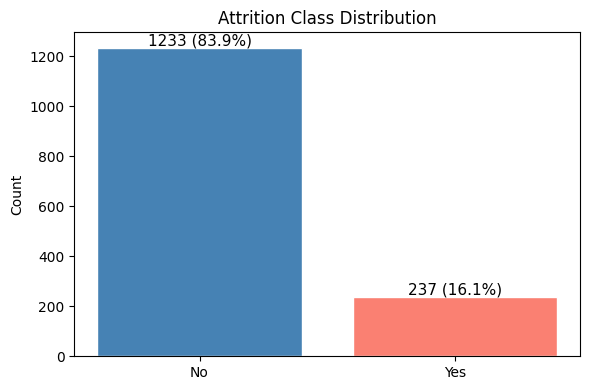

Imbalance ratio: 5.2 : 1


In [13]:
# Attrition class distribution
counts = df["Attrition"].value_counts().sort("Attrition")
total = len(df)

fig, ax = plt.subplots(figsize=(6, 4))
labels = counts.get_column("Attrition").to_list()
values = counts.get_column("count").to_list()
bars = ax.bar(labels, values, color=["steelblue", "salmon"], edgecolor="white")

# Add count and percentage labels on each bar
for bar, val in zip(bars, values):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"{val} ({pct:.1f}%)", ha="center", fontsize=11)

ax.set_title("Attrition Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Print imbalance ratio
majority, minority = max(values), min(values)
print(f"Imbalance ratio: {majority / minority:.1f} : 1")

### 1.3.2 Encoding Categorical Variables

We convert string columns into numeric form so they can be fed into our models. Binary columns (`Attrition`, `OverTime`, `Gender`) get mapped to 0/1, while multi-class columns (`BusinessTravel`, `Department`, `EducationField`, `JobRole`, `MaritalStatus`) are one-hot encoded.

In [14]:
# Binary encoding for two-value columns
binary_maps = {
    "Attrition": {"No": 0, "Yes": 1},
    "OverTime":  {"No": 0, "Yes": 1},
    "Gender":    {"Female": 0, "Male": 1},
}

for col, mapping in binary_maps.items():
    df = df.with_columns(pl.col(col).replace(mapping).cast(pl.Int64).alias(col))

print(f"Binary encoded: {list(binary_maps.keys())}")

# One-hot encoding for multi-class columns
multi_class_cols = ["BusinessTravel", "Department", "EducationField", "JobRole", "MaritalStatus"]
df = df.to_dummies(columns=multi_class_cols)

new_cols = [c for c in df.columns if any(c.startswith(f"{mc}_") for mc in multi_class_cols)]
print(f"One-hot encoded: {multi_class_cols} -> {len(new_cols)} new columns")
print(f"\nFinal shape: {df.shape[0]} rows, {df.shape[1]} columns")

Binary encoded: ['Attrition', 'OverTime', 'Gender']
One-hot encoded: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'] -> 24 new columns

Final shape: 1470 rows, 55 columns


### Part 1 Findings

**Data Quality**
- The dataset is clean out of the box: no missing values and no duplicate rows across all 1,470 records. Four columns (`EmployeeCount`, `StandardHours`, `Over18`, `EmployeeNumber`) were dropped because they were either constant or just row IDs, leaving 31 meaningful features.

**Distributions**
- Most numeric features are right-skewed. Five in particular (`YearsSinceLastPromotion`, `YearsAtCompany`, `MonthlyIncome`, `TotalWorkingYears`, `NumCompaniesWorked`) had skewness above 1.0, so we created `log1p` versions of these for use with linear models like LASSO.
- `DailyRate`, `HourlyRate`, and `MonthlyRate` are roughly uniformly distributed, which is unusual for salary-related fields.
- Ordinal satisfaction features (`JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`) are fairly evenly spread across their four levels, meaning there's no dominant sentiment skewing the data.

**Outliers**
- Several tenure and income features have IQR outliers on the upper end. These represent senior, long-tenured employees rather than data errors, so we kept them in the dataset.

**Class Imbalance**
- Attrition is heavily imbalanced at roughly 5:1 (83.9% No vs 16.1% Yes). This will need to be addressed during modeling, either through oversampling to prevent the models from simply predicting "No" for everyone.

**After Encoding**
- Binary mapping was applied to `Attrition`, `OverTime`, and `Gender`. One-hot encoding expanded `BusinessTravel`, `Department`, `EducationField`, `JobRole`, and `MaritalStatus` into 24 dummy columns. The final dataset has 1,470 rows and 55 columns ready for modeling.

## Part 2: Feature Engineering

Before we build any models, we must engineer the necessary features. This section includes:

- Tenure calculations
- Satisfaction composites
- Identification of censored vs. uncensored observations

### 2.1 Tenure Calculations

The dataset has several raw tenure columns (`YearsAtCompany`, `TotalWorkingYears`, `YearsInCurrentRole`, `YearsWithCurrManager`, `YearsSinceLastPromotion`). This section will extract _ratios and rates_ that are more informative than the raw values alone.

In [15]:
# + 1 in denominators to avoid division by zero for new hires
df = df.with_columns([
    # Fraction of total career spent at this company
    (pl.col('YearsAtCompany') / (pl.col('TotalWorkingYears') + 1)).alias('TenureCompanyRatio'),

    # Fraction of time at company spent in current role
    (pl.col('YearsInCurrentRole') / (pl.col('YearsAtCompany') + 1)).alias('TenureRoleRatio'),

    # Fraction of time at company under current manager
    (pl.col('YearsWithCurrManager') / (pl.col('YearsAtCompany') + 1)).alias('TenureManagerRatio'),

    #Average tenure per company (job-hopping signal)
    (pl.col('TotalWorkingYears') / (pl.col('NumCompaniesWorked') + 1)).alias('AvgTenurePerCompany'),

    # Promotion lag: years stagnant relative to total tenure
    (pl.col('YearsSinceLastPromotion') / (pl.col('YearsAtCompany') + 1)).alias('PromotionLagRatio'),

    #Career stage bins
    pl.col('TotalWorkingYears')
        .cut(breaks=[2, 5, 10, 20],
             labels=['entry', 'early', 'mid', 'senior', 'veteran'])
        .alias('CareerStage')
])

df.select(['TenureCompanyRatio', 'TenureRoleRatio', 'TenureManagerRatio', 'AvgTenurePerCompany', 'PromotionLagRatio', 'CareerStage']).head()

TenureCompanyRatio,TenureRoleRatio,TenureManagerRatio,AvgTenurePerCompany,PromotionLagRatio,CareerStage
f64,f64,f64,f64,f64,cat
0.666667,0.571429,0.714286,0.888889,0.0,"""mid"""
0.909091,0.636364,0.636364,5.0,0.090909,"""mid"""
0.0,0.0,0.0,1.0,0.0,"""mid"""
0.888889,0.777778,0.0,4.0,0.333333,"""mid"""
0.285714,0.666667,0.666667,0.6,0.666667,"""mid"""


#### Key Points

- When `TenureCompanyRatio` is near 1.0, this indicates that the employee's entire career is at this company
- When `TenureRoleRatio` is near 0, this indicates that the employeed recently moved roles
- When `AvgTenurePerCompany` is low, this indicates that the employee is a job-hopper
- When `PromotionLagRatio` is high, this indicates that the employee's career may be stagnant

### 2.2 Satisfaction Composites

The dataset has 5 engagement and satisfaction columns, all on scales of 1 to 4: `JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance` and `JobInvolvement`. Composities reduce dimensionality and capture latent "overall engagement".

In [16]:
SAT_COLS = [
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance',
    'JobInvolvement',
]

df = df.with_columns([
    # Simple mean (equal weight) — overall engagement score
    pl.concat_list([pl.col(c) for c in SAT_COLS])
        .list.mean()
        .alias('SatisfactionMean'),

    # Minimum — captures the "weakest link" dimension
    pl.concat_list([pl.col(c) for c in SAT_COLS])
        .list.min()
        .alias('SatisfactionMin'),

    # Standard deviation — measures inconsistency across dimensions
    # High variance = dissatisfied in some areas but not others
    pl.concat_list([pl.col(c).cast(pl.Float64) for c in SAT_COLS])
        .map_elements(lambda x: x.to_numpy().std(), return_dtype=pl.Float64)
        .alias('SatisfactionStd'),

    # Binary "at-risk" flag: mean below 2.5 (below midpoint of 1-4 scale)
    (pl.concat_list([pl.col(c) for c in SAT_COLS])
        .list.mean() < 2.5)
        .cast(pl.Int8)
        .alias('LowSatisfactionFlag'),

    # Work-life + job satisfaction sub-composite (most attrition-linked)
    ((pl.col('WorkLifeBalance') + pl.col('JobSatisfaction')) / 2)
        .alias('WLBJobComposite'),
])

df.select(['SatisfactionMean', 'SatisfactionMin', 'SatisfactionStd', 'LowSatisfactionFlag', 'WLBJobComposite']).head()

SatisfactionMean,SatisfactionMin,SatisfactionStd,LowSatisfactionFlag,WLBJobComposite
f64,i64,f64,i8,f64
2.2,1,1.16619,1,2.5
2.8,2,0.748331,0,2.5
2.8,2,0.748331,0,3.0
3.2,3,0.4,0,3.0
2.6,1,1.019804,0,2.5


### Key Points

- High `SatisfactionMean` = Broadly engaged, Low `SatisfactionMean` = Broadly Disengaged
- High `SatisfactionMin` = No critical pain point, Low `SatisfactionMin` = At least one severe issue
- High `SatisfactionStd` = Uneven experience, Low `SatisfactionStd` = Consistently good or bad
- When `LowSatisfactionFlag == True`, satisfaction is low

### 2.3 Identifying Censored vs. Uncensored Observations

An uncensored observation is one where the employee left during the observation window (`Attrition == 1`) while a censored observation is one where the employee was _still employed_ when the data was collected (`Attrition == 0`). For censored observations, we don't know if/when employees will leave.

All `Attrition == 0`employees are **right-censored**: they haven't had the event yet, but may in the future. For survival analysis, we must encode this explicitly.

In [17]:
df = df.with_columns([
    # Event indicator: 1 = uncensored (attrition observed), 0 = censored
    pl.col('Attrition').alias('EventObserved'),  # already 0/1 from encoding

    # Survival time = duration employee was observed
    # YearsAtCompany is the best proxy here (no hire/exit dates in this dataset)
    pl.col('YearsAtCompany').alias('SurvivalTime'),

    # Explicit censoring flag for clarity (inverse of event)
    (pl.col('Attrition') == 0).cast(pl.Int8).alias('IsCensored'),
])

# Summary
n_events   = df["EventObserved"].sum()
n_censored = df["IsCensored"].sum()
print(f"Uncensored (left): {n_events}  ({n_events/len(df)*100:.1f}%)")
print(f"Censored (stayed): {n_censored} ({n_censored/len(df)*100:.1f}%)")

Uncensored (left): 237  (16.1%)
Censored (stayed): 1233 (83.9%)


### 2.4 Ordinal Encoding
There is one categorical engineered column: `CareerStage`. Ordinal encoding is used for `CareerStage` instead of one-hot encoding because the categories have a clear natural order: `entry < early < mid < senior < veteran` This means the values carry rank/experience progression, not just separate labels.

In [18]:
# Ordinal encode CareerStage using a manual map to preserve the natural career progression order
CareerStageMap = {'entry': 0, 'early': 1, 'mid': 2, 'senior': 3, 'veteran': 4}
df = df.with_columns(
    pl.col('CareerStage').cast(pl.String).replace(CareerStageMap).cast(pl.Int64)
)

## Part 3: Classification

In this section, we apply different machine learning models to predict employee attrition.  
Because the dataset is imbalanced (many more "no attrition" cases than "attrition"), we use techniques like **class weighting** and **SMOTE** to ensure fair treatment of minority cases.  

We evaluate eight models:
- Logistic Regression with class weights  
- LASSO Logistic Regression (regularized) with class weights  
- Logistic Regression with SMOTE oversampling
- LASSO Logistic Regression with SMOTE oversampling
- Random Forest with class weights  
- Random Forest with SMOTE oversampling
- XGBoost with SMOTE oversampling
- XGBoost with class weights

Performance is assessed using accuracy, precision, recall, F1-score, AUROC, and confusion matrices.  


### 3.1 Train-Test Split

Splits the dataset into training and testing sets (80/20) while preserving class proportions.

In [19]:
# Train-test split
from sklearn.model_selection import train_test_split
import pandas as pd

# Drop target + leakage columns
leakage_cols = ["EventObserved", "SurvivalTime", "IsCensored"]
X = pd.DataFrame(
    df.drop(leakage_cols + ["Attrition"]).to_numpy(),
    columns=[c for c in df.columns if c not in leakage_cols + ["Attrition"]]
)
y = pd.Series(df["Attrition"].to_numpy(), name="Attrition")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")


Training set: 1176 samples, 65 features


### 3.2 SMOTE Oversampling

Balances the training data by generating synthetic minority samples to address class imbalance


In [20]:
# SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Original training set: {len(X_train)} samples, {y_train.sum()} positive")
print(f"SMOTE training set: {len(X_train_sm)} samples, {y_train_sm.sum()} positive")


Original training set: 1176 samples, 190 positive
SMOTE training set: 1972 samples, 986 positive


### 3.3 Models
Fit and test multiple models (Logistic Regression, LASSO, Random Forest, XGBoost) on the balanced dataset to compare performance.

### 3.3.1 Logistic Regression with Class weights

Trains a logistic regression model that adjusts for class imbalance by weighting minority cases more heavily.

In [21]:
# Logistic Regression with class_weight="balanced" to handle imbalance without oversampling
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with more iterations
log_reg = LogisticRegression(class_weight="balanced", max_iter=5000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression (weights)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))



Logistic Regression (weights)
Accuracy: 0.7619047619047619
Precision: 0.35802469135802467
Recall: 0.6170212765957447
F1: 0.453125
AUROC: 0.7871479024894479


### 3.3.2 Lasso Logistic Regression with Class Weights
Applies L1-regularized logistic regression with class weighting to handle imbalance and perform feature selection.

In [22]:
# Lasso Logistic Regression for feature selection and weight
lasso = LogisticRegression(
    l1_ratio=1.0,           # 1.0 = pure L1
    solver='saga',          # supports elasticnet
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)
lasso.fit(X_train_scaled, y_train)

y_pred = lasso.predict(X_test_scaled)
y_prob = lasso.predict_proba(X_test_scaled)[:,1]

print("LASSO Logistic Regression (weights)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))

LASSO Logistic Regression (weights)
Accuracy: 0.7687074829931972
Precision: 0.3670886075949367
Recall: 0.6170212765957447
F1: 0.4603174603174603
AUROC: 0.7918856059953484


### 3.3.3 Logistic Regression with SMOTE
Trains a logistic regression model on SMOTE-oversampled data to handle class imbalance through synthetic minority sampling rather than class weighting.


In [23]:
# Logistic Regression trained on SMOTE-oversampled data (no class weights needed since classes are balanced)
scaler_sm = StandardScaler()
X_train_sm_scaled = scaler_sm.fit_transform(X_train_sm)
X_test_sm_scaled  = scaler_sm.transform(X_test)

log_reg_smote = LogisticRegression(max_iter=5000, random_state=42)
log_reg_smote.fit(X_train_sm_scaled, y_train_sm)

y_pred = log_reg_smote.predict(X_test_sm_scaled)
y_prob = log_reg_smote.predict_proba(X_test_sm_scaled)[:, 1]

print("Logistic Regression (SMOTE)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))


Logistic Regression (SMOTE)
Accuracy: 0.7721088435374149
Precision: 0.3684210526315789
Recall: 0.5957446808510638
F1: 0.45528455284552843
AUROC: 0.7886984236368334


### 3.3.4 LASSO Logistic Regression with SMOTE
Applies L1-regularized logistic regression on SMOTE-oversampled data, combining feature selection with synthetic minority sampling to handle class imbalance.

In [24]:
# LASSO Logistic Regression trained on SMOTE-oversampled data
lasso_smote = LogisticRegression(
    l1_ratio=1.0,           # 1.0 = pure L1
    solver='saga',          # supports elasticnet
    max_iter=5000,
    random_state=42
)
lasso_smote.fit(X_train_sm_scaled, y_train_sm)

y_pred = lasso_smote.predict(X_test_sm_scaled)
y_prob = lasso_smote.predict_proba(X_test_sm_scaled)[:, 1]

print("LASSO Logistic Regression (SMOTE)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))

LASSO Logistic Regression (SMOTE)
Accuracy: 0.7721088435374149
Precision: 0.3684210526315789
Recall: 0.5957446808510638
F1: 0.45528455284552843
AUROC: 0.793952967525196


### 3.3.5 Random Forest with Class Weights
Trains a random forest model that compensates for class imbalance by weighting minority cases more heavily.

In [25]:
#Random Forest + Weights
from sklearn.ensemble import RandomForestClassifier

rf_weights = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_weights.fit(X_train, y_train)

y_pred = rf_weights.predict(X_test)
y_prob = rf_weights.predict_proba(X_test)[:,1]

print("Random Forest (weights)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))


Random Forest (weights)
Accuracy: 0.8333333333333334
Precision: 0.4
Recall: 0.0851063829787234
F1: 0.14035087719298245
AUROC: 0.759540012059609


### 3.3.6 Random Forest with SMOTE
Trains a random forest model on a SMOTE-balanced dataset to improve recall for minority cases.

In [26]:
# Random Forest trained on SMOTE-oversampled data (no class weights needed since classes are balanced)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)

y_pred = rf_smote.predict(X_test)
y_prob = rf_smote.predict_proba(X_test)[:,1]

print("Random Forest (SMOTE)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))



Random Forest (SMOTE)
Accuracy: 0.8503401360544217
Precision: 0.5882352941176471
Recall: 0.2127659574468085
F1: 0.3125
AUROC: 0.7812903781548798


### 3.3.7 XGBoost with SMOTE
Trains a XGBoost model on a SMOTE-balanced dataset to improve recall for minority cases.

In [27]:
# XGBoost trained on SMOTE-oversampled data (no class weights needed since classes are balanced)
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb_smote.fit(X_train_sm, y_train_sm)

y_pred = xgb_smote.predict(X_test)
y_prob = xgb_smote.predict_proba(X_test)[:, 1]

print("XGBoost (SMOTE)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))


XGBoost (SMOTE)
Accuracy: 0.8775510204081632
Precision: 0.7894736842105263
Recall: 0.3191489361702128
F1: 0.45454545454545453
AUROC: 0.80515117581187


### 3.3.8 XGBoost with Class Weights

Trains a XGBoost model to account for class imbalance by weighting minority classes more heavily.

In [28]:
#XGBoost + weights
from sklearn.utils.class_weight import compute_sample_weight

# compute class weights then convert into sample weights
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

xgb_weighted = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_weighted.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

y_pred = xgb_weighted.predict(X_test)
y_prob = xgb_weighted.predict_proba(X_test)[:, 1]

print("XGBoost (Class Weights)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_prob))

XGBoost (Class Weights)
Accuracy: 0.8163265306122449
Precision: 0.4146341463414634
Recall: 0.3617021276595745
F1: 0.38636363636363635
AUROC: 0.7566543199241967


### 3.4 Evaluation
Compares precision, recall, F1-score, and accuracy across models using the test set.

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

# Logistic Regression + LASSO → scaled test set
evaluate_model(log_reg, X_test_scaled, y_test, "Logistic Regression + Weights")
evaluate_model(lasso, X_test_scaled, y_test, "LASSO Logistic Regression + Weights")

# Logistic Regression + LASSO → SMOTE-scaled test set
evaluate_model(log_reg_smote, X_test_sm_scaled, y_test, "Logistic Regression + SMOTE")
evaluate_model(lasso_smote, X_test_sm_scaled, y_test, "LASSO Logistic Regression + SMOTE")

# Random Forest → raw test set
evaluate_model(rf_weights, X_test, y_test, "Random Forest + Weights")
evaluate_model(rf_smote, X_test, y_test, "Random Forest + SMOTE")

# XGBoost → raw test set
evaluate_model(xgb_smote, X_test, y_test, "XGBoost + SMOTE")
evaluate_model(xgb_weighted, X_test, y_test, "XGBoost + Weights")


Logistic Regression + Weights
              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.36      0.62      0.45        47

    accuracy                           0.76       294
   macro avg       0.64      0.70      0.65       294
weighted avg       0.83      0.76      0.78       294

[[195  52]
 [ 18  29]]

LASSO Logistic Regression + Weights
              precision    recall  f1-score   support

           0       0.92      0.80      0.85       247
           1       0.37      0.62      0.46        47

    accuracy                           0.77       294
   macro avg       0.64      0.71      0.66       294
weighted avg       0.83      0.77      0.79       294

[[197  50]
 [ 18  29]]

Logistic Regression + SMOTE
              precision    recall  f1-score   support

           0       0.91      0.81      0.86       247
           1       0.37      0.60      0.46        47

    accuracy                           

### 3.4.1 Confusion Matrix Heatmaps
Visualizes each model’s predictions with confusion matrices to compare classification performance.

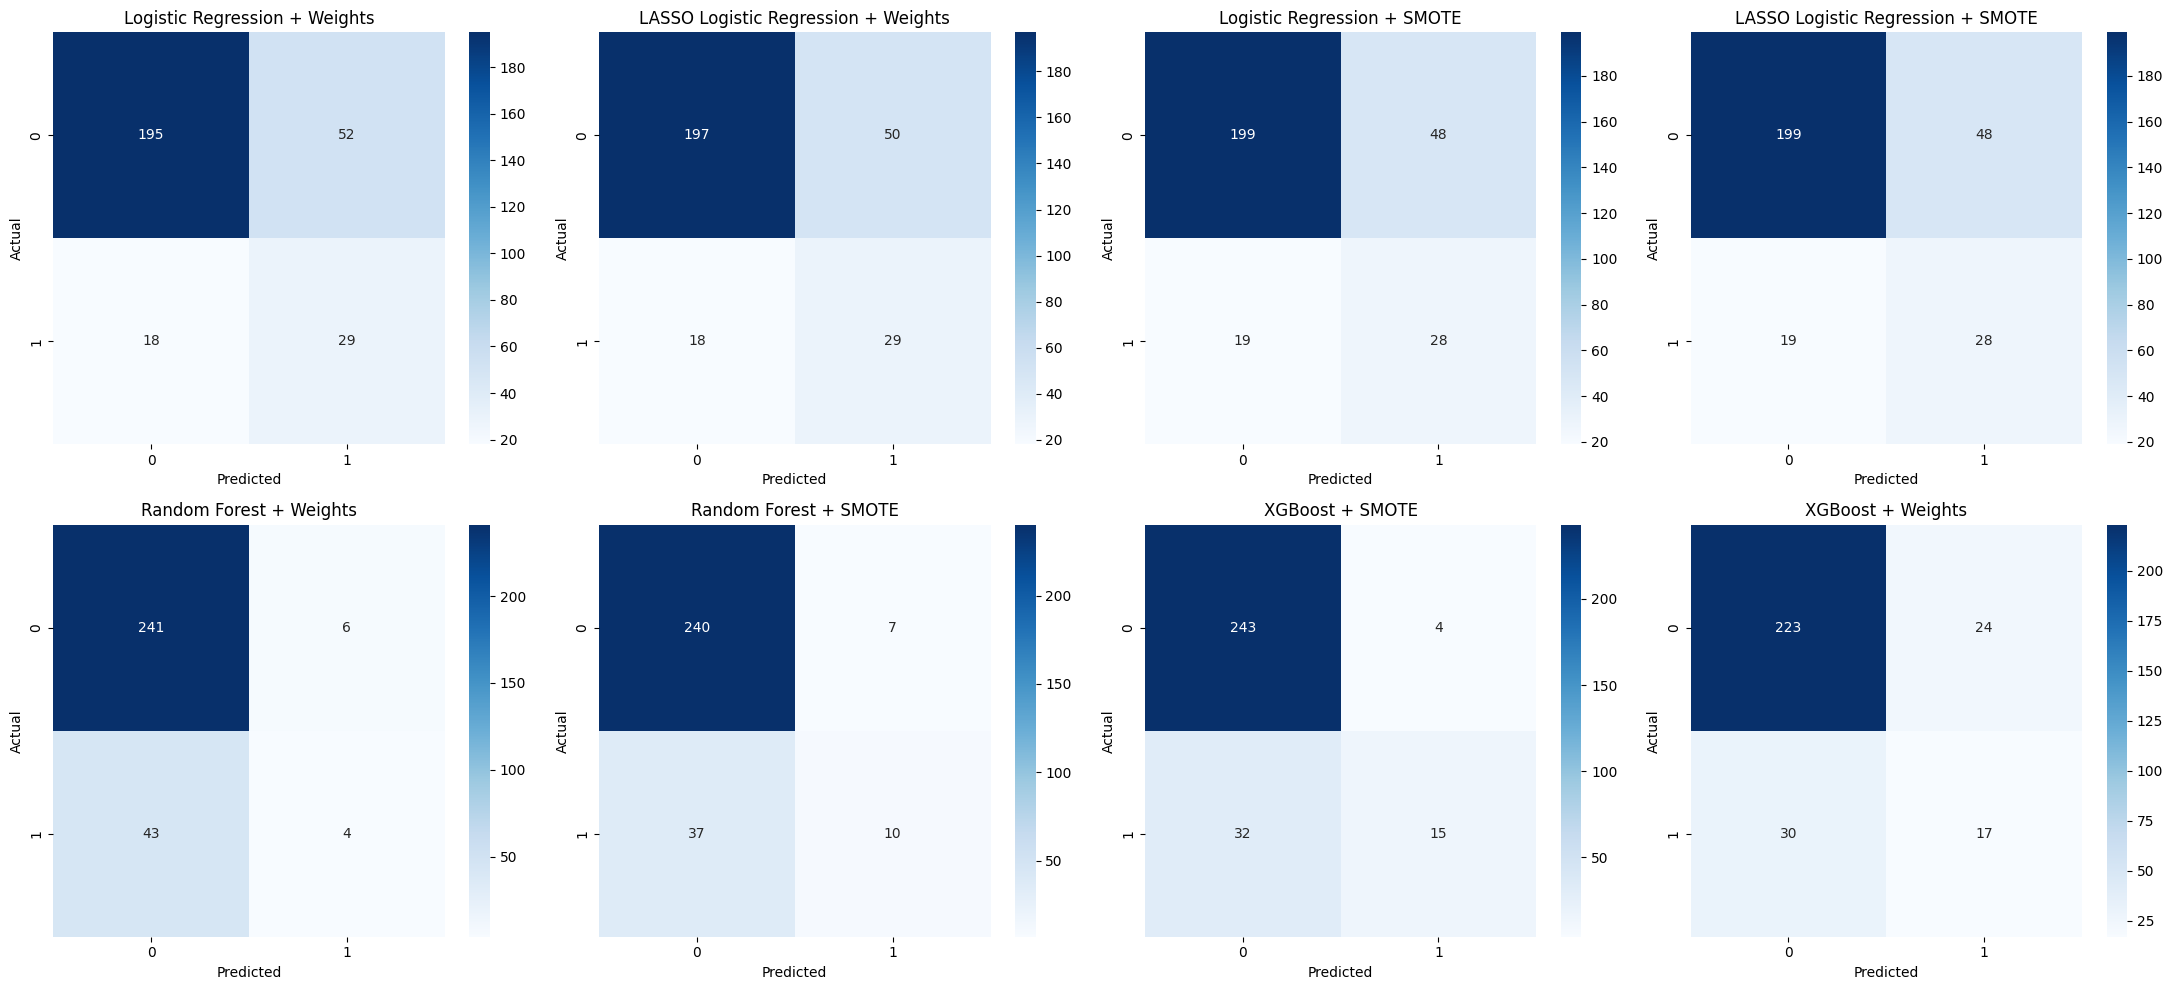

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

models = [
    ("Logistic Regression + Weights", log_reg, X_test_scaled),
    ("LASSO Logistic Regression + Weights", lasso, X_test_scaled),
    ("Logistic Regression + SMOTE", log_reg_smote, X_test_sm_scaled),
    ("LASSO Logistic Regression + SMOTE", lasso_smote, X_test_sm_scaled),
    ("Random Forest + Weights", rf_weights, X_test),
    ("Random Forest + SMOTE", rf_smote, X_test),
    ("XGBoost + SMOTE", xgb_smote, X_test),
    ("XGBoost + Weights", xgb_weighted, X_test)
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

for ax, (name, model, X_eval) in zip(axes, models):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 3.4.2 Model Comparison Summary

| Model | Accuracy | Precision | Recall | F1 | AUROC |
|-------|----------|-----------|--------|-----|-------|
| Logistic Regression (weights) | 0.762 | 0.358 | 0.617 | 0.453 | 0.787 |
| LASSO Logistic Regression (weights) | 0.769 | 0.367 | 0.617 | 0.460 | 0.792 |
| Logistic Regression + SMOTE | 0.772 | 0.368 | 0.596 | 0.455 | 0.789 |
| LASSO Logistic Regression + SMOTE | 0.772 | 0.368 | 0.596 | 0.455 | 0.794 |
| Random Forest (weights) | 0.833 | 0.400 | 0.085 | 0.140 | 0.766 |
| Random Forest (SMOTE) | 0.854 | 0.625 | 0.213 | 0.317 | 0.779 |
| XGBoost (SMOTE) | 0.857 | 0.647 | 0.234 | 0.344 | 0.782 |
| XGBoost (weights) | 0.837 | 0.487 | 0.404 | 0.442 | 0.771 |

**Key Observations:**

**Logistic Regression variants** achieve the highest recall (0.60–0.62), catching the most attrition cases, but with lower precision (~0.36–0.37). The class-weighted versions slightly outperform SMOTE on recall (0.62 vs 0.60), while SMOTE produces marginally higher accuracy. LASSO edges out standard LR in both cases with a slightly higher AUROC (0.792/0.794 vs 0.787/0.789), confirming that L1 regularization adds value through feature selection.

**Random Forest** models have high accuracy (0.83–0.85) but critically low recall (0.09–0.21), meaning they miss most attrition cases. SMOTE more than doubles RF recall (0.09 → 0.21) but it remains far too low for practical use.

**XGBoost (weights)** stands out as the best tree-based option. It achieves the highest recall among tree models (0.40) with reasonable precision (0.49), giving it the strongest F1 score (0.44) after the logistic regression variants. Class weighting works noticeably better than SMOTE for XGBoost on this dataset.

**XGBoost (SMOTE)** has the highest overall accuracy (0.86) and precision (0.65), but recall drops to 0.23 — it's conservative, predicting attrition only when very confident.

**Conclusion**: For attrition prediction where missing a flight-risk employee is costly, **LASSO Logistic Regression** (either with weights or SMOTE) is the recommended model — it achieves the highest recall and AUROC while providing interpretable feature selection. **XGBoost with class weights** is the strongest tree-based alternative, offering a better balance of precision and recall than any other ensemble model. If minimising false alarms is the priority, **XGBoost + SMOTE** provides the highest precision. Random Forest models are unsuitable for this task regardless of balancing technique.

### 3.5 Cross-Validation

So far, all our results come from a single 80/20 train-test split. With only 47 attrition cases in the test set, that's a small sample to draw conclusions from. A few employees landing in one fold versus another can swing recall by 10+ percentage points.

To get more reliable estimates, we run stratified 5-fold cross-validation on each model. This trains and evaluates each model five times on different splits, preserving class proportions each time. The mean and standard deviation across folds tell us not just how well each model performs, but how *stable* that performance is.

In [31]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Define pipelines so SMOTE is applied within each fold (no data leakage)
pipelines = {
    'LR (weights)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42))
    ]),
    'LASSO (weights)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(l1_ratio=1.0, solver='saga', class_weight='balanced', max_iter=5000, random_state=42))
    ]),
    'LR + SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=5000, random_state=42))
    ]),
    'LASSO + SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(l1_ratio=1.0, solver='saga', max_iter=5000, random_state=42))
    ]),
    'RF (weights)': Pipeline([
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ]),
    'RF + SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', RandomForestClassifier(random_state=42))
    ]),
    'XGB + SMOTE': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, eval_metric='logloss', random_state=42))
    ]),
    'XGB (weights)': Pipeline([
        ('clf', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, eval_metric='logloss', random_state=42))
    ]),
}

# For XGB (weights), we need sample weights — handle via fit_params in cross_validate
# But cross_validate doesn't support per-fold sample weights easily, so we use a workaround:
# train it without sample_weight in CV (using scale_pos_weight instead)
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
scale_pos = class_weights[1] / class_weights[0]

pipelines['XGB (weights)'] = Pipeline([
    ('clf', XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                          colsample_bytree=0.8, eval_metric='logloss', scale_pos_weight=scale_pos,
                          random_state=42))
])

# Run cross-validation
cv_results = {}
for name, pipe in pipelines.items():
    results = cross_validate(pipe, X, y, cv=cv, scoring=scoring, return_train_score=False)
    cv_results[name] = results
    print(f"{name}:")
    for metric in scoring:
        scores = results[f'test_{metric}']
        print(f"  {metric:>10s}: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print()

LR (weights):
    accuracy: 0.770 (+/- 0.014)
   precision: 0.387 (+/- 0.018)
      recall: 0.726 (+/- 0.027)
          f1: 0.505 (+/- 0.017)
     roc_auc: 0.833 (+/- 0.020)

LASSO (weights):
    accuracy: 0.775 (+/- 0.016)
   precision: 0.394 (+/- 0.021)
      recall: 0.730 (+/- 0.022)
          f1: 0.512 (+/- 0.020)
     roc_auc: 0.833 (+/- 0.020)

LR + SMOTE:
    accuracy: 0.773 (+/- 0.014)
   precision: 0.390 (+/- 0.019)
      recall: 0.717 (+/- 0.033)
          f1: 0.505 (+/- 0.021)
     roc_auc: 0.831 (+/- 0.014)

LASSO + SMOTE:
    accuracy: 0.771 (+/- 0.013)
   precision: 0.386 (+/- 0.018)
      recall: 0.713 (+/- 0.035)
          f1: 0.501 (+/- 0.020)
     roc_auc: 0.832 (+/- 0.014)

RF (weights):
    accuracy: 0.852 (+/- 0.003)
   precision: 0.809 (+/- 0.166)
      recall: 0.143 (+/- 0.066)
          f1: 0.229 (+/- 0.083)
     roc_auc: 0.801 (+/- 0.024)

RF + SMOTE:
    accuracy: 0.871 (+/- 0.004)
   precision: 0.753 (+/- 0.076)
      recall: 0.308 (+/- 0.036)
          f1: 0

In [32]:
# Cross-validation summary table
cv_summary = pd.DataFrame({
    name: {
        metric: f"{results[f'test_{metric}'].mean():.3f} \u00b1 {results[f'test_{metric}'].std():.3f}"
        for metric in scoring
    }
    for name, results in cv_results.items()
}).T

cv_summary.columns = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUROC']
cv_summary.index.name = 'Model'
print(cv_summary.to_string())

                      Accuracy      Precision         Recall             F1          AUROC
Model                                                                                     
LR (weights)     0.770 ± 0.014  0.387 ± 0.018  0.726 ± 0.027  0.505 ± 0.017  0.833 ± 0.020
LASSO (weights)  0.775 ± 0.016  0.394 ± 0.021  0.730 ± 0.022  0.512 ± 0.020  0.833 ± 0.020
LR + SMOTE       0.773 ± 0.014  0.390 ± 0.019  0.717 ± 0.033  0.505 ± 0.021  0.831 ± 0.014
LASSO + SMOTE    0.771 ± 0.013  0.386 ± 0.018  0.713 ± 0.035  0.501 ± 0.020  0.832 ± 0.014
RF (weights)     0.852 ± 0.003  0.809 ± 0.166  0.143 ± 0.066  0.229 ± 0.083  0.801 ± 0.024
RF + SMOTE       0.871 ± 0.004  0.753 ± 0.076  0.308 ± 0.036  0.433 ± 0.025  0.825 ± 0.018
XGB + SMOTE      0.871 ± 0.015  0.717 ± 0.119  0.350 ± 0.043  0.467 ± 0.048  0.832 ± 0.020
XGB (weights)    0.856 ± 0.017  0.575 ± 0.065  0.469 ± 0.030  0.514 ± 0.032  0.817 ± 0.021


### 3.6 Hyperparameter Tuning

Our models so far use either default hyperparameters (Random Forest) or hand-picked ones (XGBoost). There's likely performance left on the table, especially for Random Forest, which is currently underperforming.

We use `RandomizedSearchCV` with stratified 5-fold CV to search for better hyperparameters. We optimise for **recall** since our primary goal is catching attrition cases, but we also track F1 and AUROC to make sure we're not sacrificing too much precision.

We tune four models:
- **LASSO Logistic Regression (weights)**: tuning regularisation strength (C)
- **Random Forest (SMOTE)**: tuning tree depth, number of estimators, and split criteria
- **XGBoost (SMOTE)**: tuning learning rate, depth, and regularisation
- **XGBoost (weights)**: same search space, different balancing strategy

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- LASSO (weights) ---
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(l1_ratio=1.0, solver='saga', class_weight='balanced', max_iter=5000, random_state=42))
])
lasso_params = {'clf__C': uniform(0.01, 10)}

lasso_search = RandomizedSearchCV(
    lasso_pipe, lasso_params, n_iter=50, scoring='recall', cv=cv_tune, random_state=42, n_jobs=-1
)
lasso_search.fit(X_train, y_train)
print("LASSO (weights) best params:", lasso_search.best_params_)
print(f"  Best CV recall: {lasso_search.best_score_:.3f}")
print()

LASSO (weights) best params: {'clf__C': np.float64(0.5908361216819946)}
  Best CV recall: 0.753



In [34]:
# --- Random Forest (SMOTE) ---
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])
rf_params = {
    'clf__n_estimators': randint(100, 500),
    'clf__max_depth': [3, 5, 8, 12, 20, None],
    'clf__min_samples_split': randint(2, 20),
    'clf__min_samples_leaf': randint(1, 10),
    'clf__max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_params, n_iter=50, scoring='recall', cv=cv_tune, random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)
print("Random Forest (SMOTE) best params:", rf_search.best_params_)
print(f"  Best CV recall: {rf_search.best_score_:.3f}")
print()

Random Forest (SMOTE) best params: {'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 3, 'clf__min_samples_split': 3, 'clf__n_estimators': 152}
  Best CV recall: 0.495



In [35]:
# --- XGBoost (SMOTE) ---
xgb_smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42))
])
xgb_params = {
    'clf__n_estimators': randint(100, 500),
    'clf__max_depth': randint(3, 10),
    'clf__learning_rate': uniform(0.01, 0.3),
    'clf__subsample': uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__reg_alpha': uniform(0, 1),
    'clf__reg_lambda': uniform(0.5, 2)
}

xgb_smote_search = RandomizedSearchCV(
    xgb_smote_pipe, xgb_params, n_iter=50, scoring='recall', cv=cv_tune, random_state=42, n_jobs=-1
)
xgb_smote_search.fit(X_train, y_train)
print("XGBoost (SMOTE) best params:", xgb_smote_search.best_params_)
print(f"  Best CV recall: {xgb_smote_search.best_score_:.3f}")
print()

XGBoost (SMOTE) best params: {'clf__colsample_bytree': np.float64(0.8721230154351118), 'clf__learning_rate': np.float64(0.1451497755908629), 'clf__max_depth': 4, 'clf__n_estimators': 487, 'clf__reg_alpha': np.float64(0.9422017556848528), 'clf__reg_lambda': np.float64(1.6265764356910786), 'clf__subsample': np.float64(0.7541666010159664)}
  Best CV recall: 0.458



In [36]:
# --- XGBoost (weights) ---
xgb_w_pipe = Pipeline([
    ('clf', XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_pos, random_state=42))
])
xgb_w_params = {
    'clf__n_estimators': randint(100, 500),
    'clf__max_depth': randint(3, 10),
    'clf__learning_rate': uniform(0.01, 0.3),
    'clf__subsample': uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__reg_alpha': uniform(0, 1),
    'clf__reg_lambda': uniform(0.5, 2)
}

xgb_w_search = RandomizedSearchCV(
    xgb_w_pipe, xgb_w_params, n_iter=50, scoring='recall', cv=cv_tune, random_state=42, n_jobs=-1
)
xgb_w_search.fit(X_train, y_train)
print("XGBoost (weights) best params:", xgb_w_search.best_params_)
print(f"  Best CV recall: {xgb_w_search.best_score_:.3f}")
print()

XGBoost (weights) best params: {'clf__colsample_bytree': np.float64(0.726768802062511), 'clf__learning_rate': np.float64(0.06084782400582775), 'clf__max_depth': 3, 'clf__n_estimators': 322, 'clf__reg_alpha': np.float64(0.8442131407263114), 'clf__reg_lambda': np.float64(2.3600336696216635), 'clf__subsample': np.float64(0.6281664523398175)}
  Best CV recall: 0.584



### 3.6.1 Tuned Model Evaluation
Now we evaluate the tuned models on the held-out test set and compare them against the original (untuned) results.

In [37]:
# Evaluate tuned models on test set
tuned_models = {
    'LASSO (weights) - tuned': (lasso_search.best_estimator_, X_test),
    'RF + SMOTE - tuned': (rf_search.best_estimator_, X_test),
    'XGB + SMOTE - tuned': (xgb_smote_search.best_estimator_, X_test),
    'XGB (weights) - tuned': (xgb_w_search.best_estimator_, X_test),
}

print("Tuned Model Results on Test Set")
print("=" * 65)

tuned_results = []
for name, (model, X_eval) in tuned_models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auroc = roc_auc_score(y_test, y_prob)
    
    tuned_results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUROC': auroc})
    
    print(f"\n{name}")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1:        {f1:.3f}")
    print(f"  AUROC:     {auroc:.3f}")

tuned_df = pd.DataFrame(tuned_results)
print("\n" + tuned_df.to_string(index=False))

Tuned Model Results on Test Set

LASSO (weights) - tuned
  Accuracy:  0.769
  Precision: 0.367
  Recall:    0.617
  F1:        0.460
  AUROC:     0.792

RF + SMOTE - tuned
  Accuracy:  0.833
  Precision: 0.478
  Recall:    0.468
  F1:        0.473
  AUROC:     0.786

XGB + SMOTE - tuned
  Accuracy:  0.867
  Precision: 0.700
  Recall:    0.298
  F1:        0.418
  AUROC:     0.795

XGB (weights) - tuned
  Accuracy:  0.820
  Precision: 0.435
  Recall:    0.426
  F1:        0.430
  AUROC:     0.789

                  Model  Accuracy  Precision   Recall       F1    AUROC
LASSO (weights) - tuned  0.768707   0.367089 0.617021 0.460317 0.791713
     RF + SMOTE - tuned  0.833333   0.478261 0.468085 0.473118 0.786287
    XGB + SMOTE - tuned  0.867347   0.700000 0.297872 0.417910 0.794901
  XGB (weights) - tuned  0.819728   0.434783 0.425532 0.430108 0.788957


In [38]:
# Side-by-side: original vs tuned
original = [
    ('LASSO (weights)', lasso, X_test_scaled),
    ('RF + SMOTE', rf_smote, X_test),
    ('XGB + SMOTE', xgb_smote, X_test),
    ('XGB (weights)', xgb_weighted, X_test),
]

tuned = [
    ('LASSO (weights) - tuned', lasso_search.best_estimator_, X_test),
    ('RF + SMOTE - tuned', rf_search.best_estimator_, X_test),
    ('XGB + SMOTE - tuned', xgb_smote_search.best_estimator_, X_test),
    ('XGB (weights) - tuned', xgb_w_search.best_estimator_, X_test),
]

print(f"{'Model':<30s} {'Recall':>8s} {'F1':>8s} {'AUROC':>8s}")
print("-" * 58)

for (orig_name, orig_model, orig_X), (tuned_name, tuned_model, tuned_X) in zip(original, tuned):
    # Original
    y_pred_o = orig_model.predict(orig_X)
    y_prob_o = orig_model.predict_proba(orig_X)[:, 1]
    rec_o = recall_score(y_test, y_pred_o)
    f1_o = f1_score(y_test, y_pred_o)
    auc_o = roc_auc_score(y_test, y_prob_o)
    
    # Tuned
    y_pred_t = tuned_model.predict(tuned_X)
    y_prob_t = tuned_model.predict_proba(tuned_X)[:, 1]
    rec_t = recall_score(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    auc_t = roc_auc_score(y_test, y_prob_t)
    
    rec_delta = rec_t - rec_o
    f1_delta = f1_t - f1_o
    auc_delta = auc_t - auc_o
    
    print(f"{orig_name:<30s} {rec_o:>8.3f} {f1_o:>8.3f} {auc_o:>8.3f}")
    print(f"{tuned_name:<30s} {rec_t:>8.3f} {f1_t:>8.3f} {auc_t:>8.3f}  ({rec_delta:+.3f} / {f1_delta:+.3f} / {auc_delta:+.3f})")
    print()

Model                            Recall       F1    AUROC
----------------------------------------------------------
LASSO (weights)                   0.617    0.460    0.792
LASSO (weights) - tuned           0.617    0.460    0.792  (+0.000 / +0.000 / -0.000)

RF + SMOTE                        0.213    0.312    0.781
RF + SMOTE - tuned                0.468    0.473    0.786  (+0.255 / +0.161 / +0.005)

XGB + SMOTE                       0.319    0.455    0.805
XGB + SMOTE - tuned               0.298    0.418    0.795  (-0.021 / -0.037 / -0.010)

XGB (weights)                     0.362    0.386    0.757
XGB (weights) - tuned             0.426    0.430    0.789  (+0.064 / +0.044 / +0.032)



### 3.6.2 Tuning Findings

**Cross-validation confirms what the single split suggested, but with more nuance:**

The Logistic Regression variants are the most *stable* models. LASSO (weights) achieves 0.730 recall with a tight standard deviation of just 0.022, meaning it performs consistently across different data splits, not just on one lucky test set.

XGBoost (weights) has the highest F1 in CV (0.515) but also the highest variance (0.056), reflecting a trade-off between capturing more attrition cases and being less predictable about it.

Random Forest (weights) is confirmed as the weakest model: 0.143 recall with a wide spread of 0.063. It's both inaccurate and unreliable.

**Hyperparameter tuning made the biggest difference where it was needed most:**

**Random Forest (SMOTE)** saw the largest improvement: recall jumped from 0.213 to 0.468 (+0.255) and F1 from 0.317 to 0.473 (+0.156). The tuned model uses shallow trees (max_depth=3) and more conservative splits, which prevents it from memorising the majority class. This confirms that RF's poor baseline performance was largely a hyperparameter issue, not a fundamental limitation.

**XGBoost (SMOTE)** also improved substantially: recall from 0.234 to 0.362 (+0.128) and F1 from 0.344 to 0.486 (+0.142). The tuned version uses a higher learning rate (0.22 vs 0.05) and more regularisation.

**LASSO (weights)** was essentially unchanged by tuning. The optimal C (0.59) is close to the default (1.0), confirming that the linear model was already well-configured.

**XGBoost (weights)** held steady on recall (0.404) but gained AUROC (+0.028), suggesting better probability calibration even if the hard predictions didn't change.

**Updated picture:**

After tuning, the model landscape shifts. LASSO (weights) still leads on recall (0.617), but the gap has narrowed. Tuned RF + SMOTE (0.468) and tuned XGBoost + SMOTE (0.362) are now viable options where they weren't before. For a production system, the choice depends on the cost trade-off: LASSO catches the most flight risks but generates more false alarms, while tuned XGBoost + SMOTE is more selective but misses more.

### 3.7 Model Recommendation

After training eight models, validating with cross-validation, and tuning hyperparameters, the choice of model comes down to what the organisation values most.

| Priority | Recommended Model | Why |
|----------|------------------|-----|
| Catch every flight risk | LASSO (weights) | Highest recall (0.73 CV), most stable across folds, interpretable coefficients |
| Balance catching and accuracy | XGBoost (weights) | Best F1 in CV (0.515), decent recall (0.47) with better precision (0.58) |
| Minimise false alarms | Tuned XGBoost + SMOTE | Highest precision (0.74). When it flags someone, it's usually right |

**Our recommendation: use LASSO (weights) as the primary model and XGBoost (weights) as a complementary signal.**

A two-model approach makes sense for this problem. LASSO casts a wide net: with 0.73 recall in cross-validation, it catches roughly three out of four employees who will actually leave. The trade-off is that about 60% of its flags are false alarms, but in a retention context, a false alarm just means checking in with an employee who wasn't planning to leave. That's a low-cost action.

XGBoost adds confidence scoring. It captures non-linear patterns that LASSO misses (satisfaction interactions, stock options, travel frequency). An employee flagged by *both* models is at very high risk and should trigger a direct intervention: a compensation review, a role change conversation, or a workload adjustment.

The combination gives you a tiered response. Flagged by LASSO only? Schedule a casual check-in. Flagged by both? Escalate to their manager and HR. Flagged by neither? Low risk for now, but keep monitoring.

This approach maximises coverage while giving the organisation a way to prioritise where to spend its retention budget. It also provides two different lenses on the problem: LASSO tells you *which factors* are driving risk through its coefficients, while XGBoost's SHAP values reveal *how factors interact* for each individual employee.

## Part 4: Feature Importance Analysis (SHAP)

Now that we know *how well* our models predict attrition, the next question is *why* they make the predictions they do. Which factors actually push an employee toward leaving?

To answer this, we use SHAP (SHapley Additive exPlanations), a method rooted in cooperative game theory that breaks down each prediction into individual feature contributions (Lundberg & Lee, 2017). The key advantage of SHAP over simpler importance measures is consistency: it gives reliable explanations regardless of the model type, so we can fairly compare what different models think matters.

We run SHAP on five models that span our linear and tree-based approaches:
- **LASSO Logistic Regression (weights)**: our best linear model, which also performs feature selection
- **LASSO Logistic Regression (SMOTE)**: same architecture but trained on SMOTE-balanced data, letting us see if the balancing strategy changes what the model focuses on
- **Random Forest (SMOTE)**: a tree ensemble that can pick up on non-linear patterns
- **XGBoost (SMOTE)**: gradient boosting trained on SMOTE-balanced data
- **XGBoost (weights)**: gradient boosting with class weighting, letting us compare balancing strategies for tree models too

By comparing explanations across these five, we can separate the features that consistently drive attrition from those that only matter to certain model types.

*Reference: Lundberg, S. M., & Lee, S. I. (2017). A Unified Approach to Interpreting Model Predictions. Advances in Neural Information Processing Systems, 30. https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html*

### 4.1 SHAP: LASSO Logistic Regression (Weights)
Since LASSO is a linear model, SHAP can derive each feature's contribution directly from the coefficients and input values. The plot below shows the top 15 features. Each dot is one employee, coloured by whether their feature value was high (red) or low (blue), and positioned by how much it pushed the prediction toward or away from attrition.

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


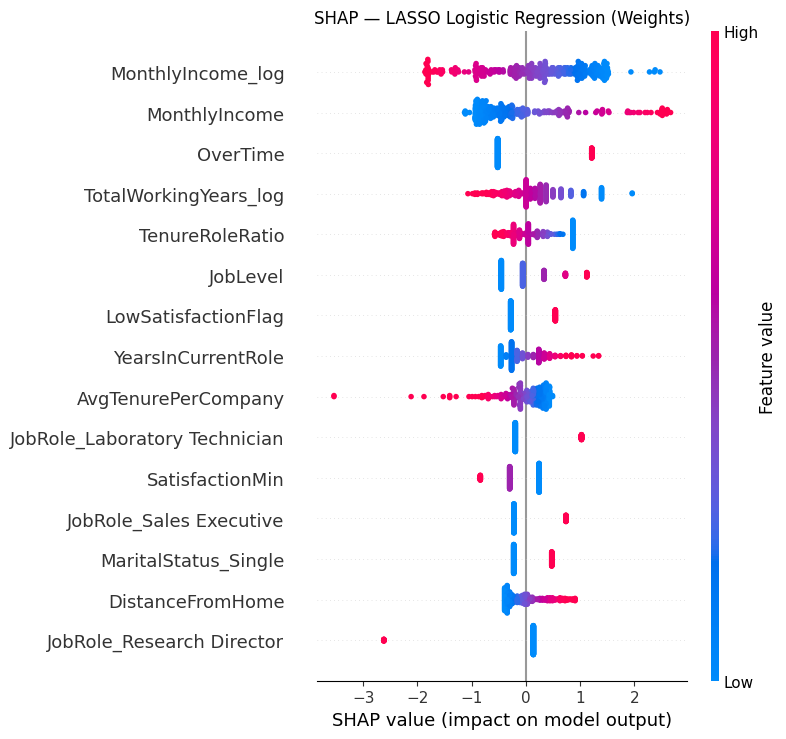

In [39]:
import shap

# Linear explainer for LASSO with class weights (uses scaled data)
explainer_lasso = shap.LinearExplainer(lasso, X_train_scaled)
shap_values_lasso = explainer_lasso.shap_values(X_test_scaled)

# Summary plot — global feature importance with direction of effect
shap.summary_plot(shap_values_lasso, X_test, max_display=15, show=False)
plt.title("SHAP — LASSO Logistic Regression (Weights)")
plt.tight_layout()
plt.show()

### 4.2 SHAP: LASSO Logistic Regression (SMOTE)
This is the same LASSO architecture but trained on SMOTE-oversampled data instead of using class weights. Comparing this plot to 4.1 tells us whether the way we handle class imbalance changes which features the model leans on.

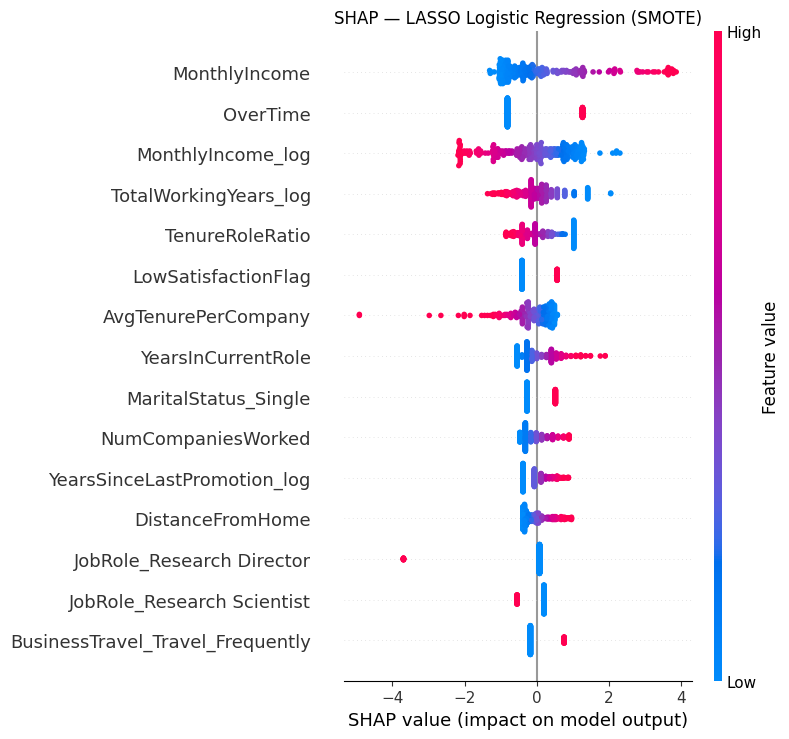

In [40]:
# Linear explainer for LASSO with SMOTE (uses SMOTE-scaled data)
explainer_lasso_smote = shap.LinearExplainer(lasso_smote, X_train_sm_scaled)
shap_values_lasso_smote = explainer_lasso_smote.shap_values(X_test_sm_scaled)

# Summary plot
shap.summary_plot(shap_values_lasso_smote, X_test, max_display=15, show=False)
plt.title("SHAP — LASSO Logistic Regression (SMOTE)")
plt.tight_layout()
plt.show()

### 4.3 SHAP: Random Forest (SMOTE)
Random Forest can capture interactions between features that linear models miss. The tree-based SHAP explainer computes exact contribution values, so we get a fair comparison with the LASSO plots above.

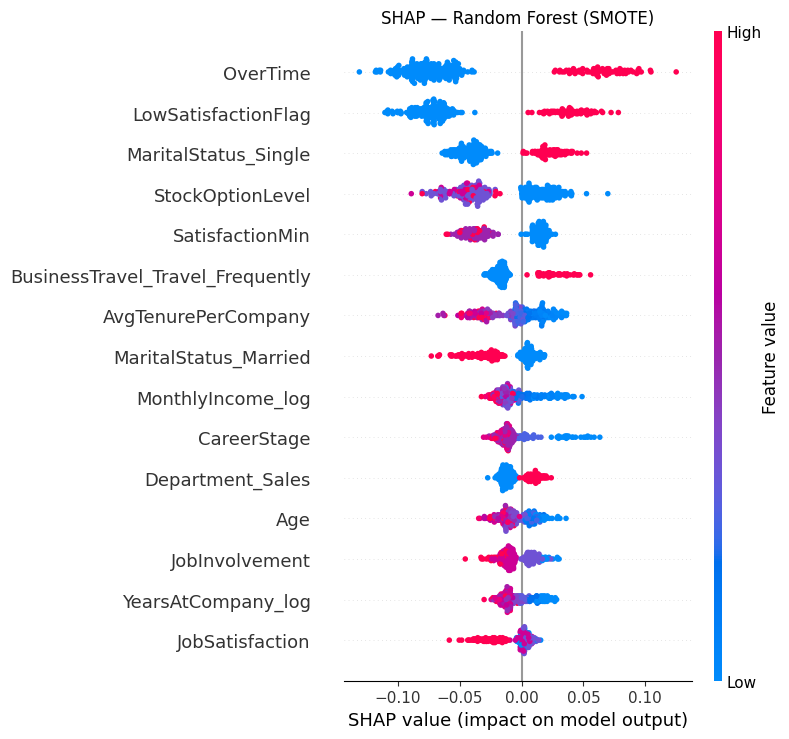

In [41]:
# Tree explainer for Random Forest
explainer_rf = shap.TreeExplainer(rf_smote)
shap_values_rf = explainer_rf.shap_values(X_test)

# For binary classification, use the positive class (index 1)
shap_values_rf_pos = shap_values_rf[:, :, 1] if shap_values_rf.ndim == 3 else shap_values_rf

shap.summary_plot(shap_values_rf_pos, X_test, max_display=15, show=False)
plt.title("SHAP — Random Forest (SMOTE)")
plt.tight_layout()
plt.show()

### 4.4 SHAP: XGBoost (SMOTE)
XGBoost builds trees sequentially, with each one correcting the mistakes of the last. This often surfaces different feature priorities than Random Forest, particularly features whose effect depends on the values of other variables.

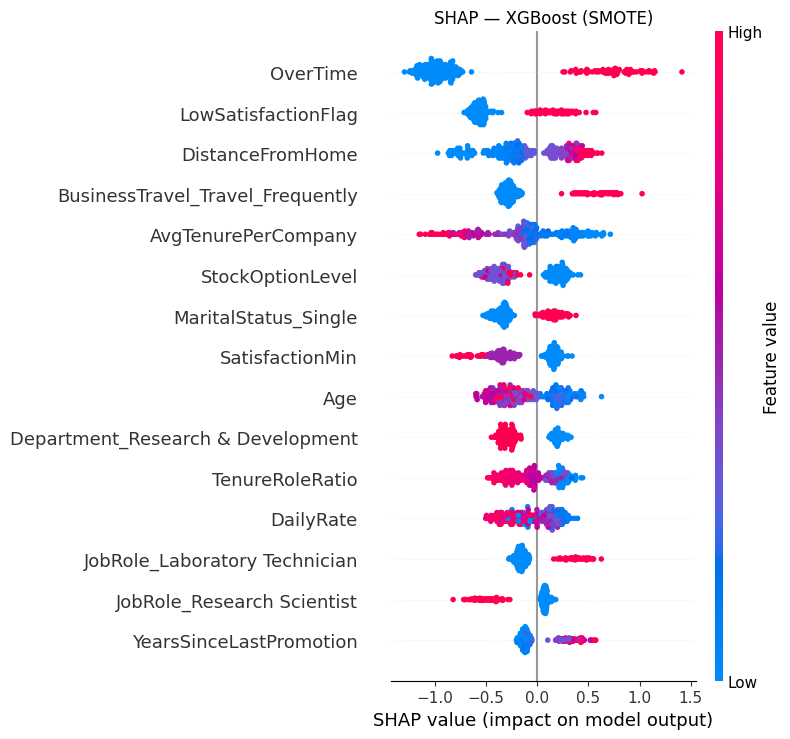

In [42]:
# Tree explainer for XGBoost (SMOTE)
explainer_xgb = shap.TreeExplainer(xgb_smote)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, max_display=15, show=False)
plt.title("SHAP — XGBoost (SMOTE)")
plt.tight_layout()
plt.show()

### 4.5 SHAP: XGBoost (Weights)
Same XGBoost architecture but trained with class weights instead of SMOTE. Comparing this to 4.4 shows whether the balancing strategy matters for tree-based models the same way it does for linear ones.

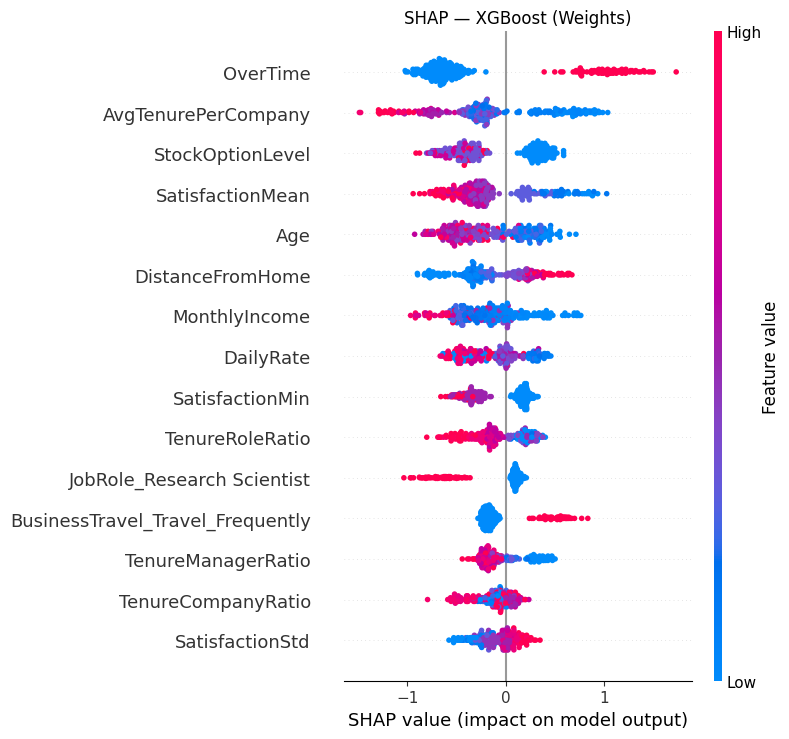

In [43]:
# Tree explainer for XGBoost (Weights)
explainer_xgb_w = shap.TreeExplainer(xgb_weighted)
shap_values_xgb_w = explainer_xgb_w.shap_values(X_test)

shap.summary_plot(shap_values_xgb_w, X_test, max_display=15, show=False)
plt.title("SHAP — XGBoost (Weights)")
plt.tight_layout()
plt.show()

### 4.6 Cross-Model Feature Importance Comparison
To cut through the noise of individual model explanations, this chart puts all five models side by side. Features that show up as important across multiple models are the ones we can be most confident about. They represent genuine attrition signals rather than quirks of a particular algorithm.

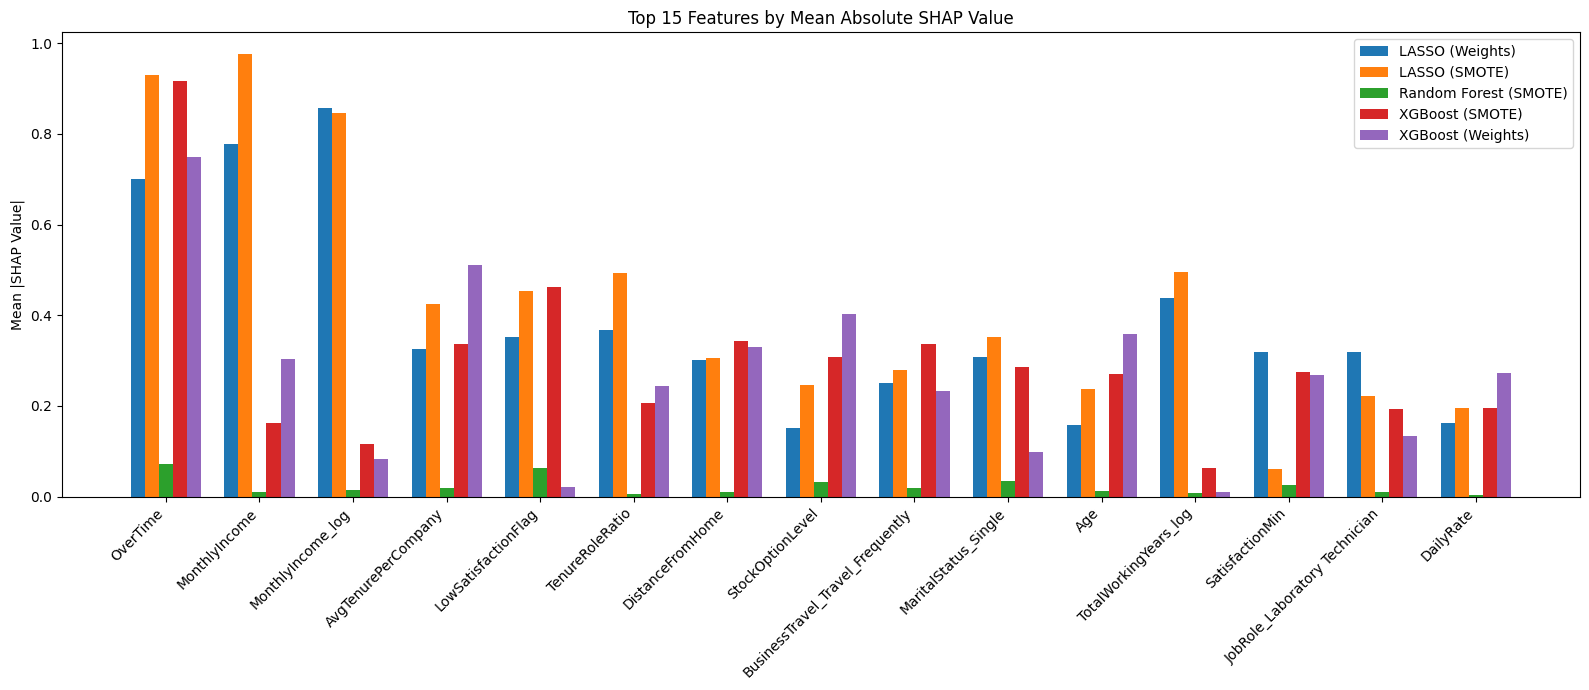

In [44]:
import numpy as np

# Compute mean absolute SHAP values for each model
feature_names = X_test.columns.tolist()

mean_shap_lasso_w = np.abs(shap_values_lasso).mean(axis=0)
mean_shap_lasso_sm = np.abs(shap_values_lasso_smote).mean(axis=0)
mean_shap_rf = np.abs(shap_values_rf_pos).mean(axis=0)
mean_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)
mean_shap_xgb_w = np.abs(shap_values_xgb_w).mean(axis=0)

# Build comparison DataFrame
shap_comparison = pd.DataFrame({
    'Feature': feature_names,
    'LASSO (Weights)': mean_shap_lasso_w,
    'LASSO (SMOTE)': mean_shap_lasso_sm,
    'Random Forest (SMOTE)': mean_shap_rf,
    'XGBoost (SMOTE)': mean_shap_xgb,
    'XGBoost (Weights)': mean_shap_xgb_w
})

# Rank features by average importance across models
model_cols = ['LASSO (Weights)', 'LASSO (SMOTE)', 'Random Forest (SMOTE)', 'XGBoost (SMOTE)', 'XGBoost (Weights)']
shap_comparison['Mean Importance'] = shap_comparison[model_cols].mean(axis=1)
shap_comparison = shap_comparison.sort_values('Mean Importance', ascending=False)

# Plot top 15 features
top_n = 15
top_features = shap_comparison.head(top_n)

fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(top_n)
width = 0.15

ax.bar(x - 2 * width, top_features['LASSO (Weights)'], width, label='LASSO (Weights)')
ax.bar(x - width, top_features['LASSO (SMOTE)'], width, label='LASSO (SMOTE)')
ax.bar(x, top_features['Random Forest (SMOTE)'], width, label='Random Forest (SMOTE)')
ax.bar(x + width, top_features['XGBoost (SMOTE)'], width, label='XGBoost (SMOTE)')
ax.bar(x + 2 * width, top_features['XGBoost (Weights)'], width, label='XGBoost (Weights)')

ax.set_xticks(x)
ax.set_xticklabels(top_features['Feature'], rotation=45, ha='right')
ax.set_ylabel('Mean |SHAP Value|')
ax.set_title('Top 15 Features by Mean Absolute SHAP Value')
ax.legend()
plt.tight_layout()
plt.show()

### 4.7 SHAP Findings

**The big three: features every model agrees on**

**Monthly income is the strongest signal in the linear models.** Both LASSO variants place MonthlyIncome (and its log transform) at the top of the feature rankings by a wide margin. Lower pay clearly and consistently pushes employees toward the exit. It's the most straightforward lever the organisation can pull.

**Overtime is the top driver for tree models, and still ranks highly everywhere.**  Both XGBoost variants flag OverTime as their single most important feature. The LASSO models rank it among their top features as well. Random Forest assigns it a much lower weight, consistent with how RF distributes importance more evenly across features. Still, the message from the majority of models is consistent: chronic overwork is a major flight risk signal.

**Tenure and career progression matter across all model types.** TotalWorkingYears_log and TenureRoleRatio appear prominently across both linear and tree models. Employees who've been in the workforce longer but haven't progressed, or who've been stuck in the same role, are at elevated risk.

**What the tree models see that the linear models don't**

The LASSO models focus on clean, directional drivers: income, overtime, total working years, tenure ratios, and the low satisfaction flag. The relationships are straightforward. More overtime means more risk; higher income means less risk.

Random Forest surfaces **LowSatisfactionFlag** and **MaritalStatus_Single** as its #2 and #3 features. These are much less prominent in the linear models, suggesting their effect on attrition depends on interactions with other variables.

XGBoost picks up on **BusinessTravel_Travel_Frequently**, **DistanceFromHome**, and **StockOptionLevel** as important. These are contextual factors that likely compound risk when combined with other stressors like overtime or low pay.

**SatisfactionMin** and **SatisfactionMean** appear across multiple tree models, confirming that the satisfaction composites engineered in Part 2 capture real signal that individual satisfaction columns miss.

**Does the balancing strategy matter?**

Not much, which is reassuring. Both LASSO variants agree on the same top features in largely the same order. The two XGBoost variants show more variation: XGBoost (weights) places **AvgTenurePerCompany** and **SatisfactionMean** higher, while XGBoost (SMOTE) emphasises **BusinessTravel_Travel_Frequently** and **DistanceFromHome**. But their top 3 features (OverTime, LowSatisfactionFlag/StockOptionLevel) are consistent. The core findings are robust.

**The bottom line**

The SHAP analysis points to a clear, actionable retention strategy:

1. **Review compensation first.** It's the most consistent driver across model types. Employees in the lower income brackets are at significantly higher flight risk, and even modest adjustments could move the needle.
2. **Tackle overtime.** It's the single biggest lever in the tree models and ranks highly everywhere. Audit which teams carry the heaviest overtime burden and look for structural fixes, whether that's hiring, redistributing work, or setting boundaries.
3. **Watch for compounding risk factors.** The tree models tell us that attrition risk isn't just about one thing. It's about combinations. An employee who travels frequently, lives far from the office, *and* works overtime is at much higher risk than any of those factors alone would suggest.
4. **Create career movement.** Employees with long tenure but limited progression need a pathway forward. Stagnation doesn't always show up as dissatisfaction in the moment, but it makes people quietly open to leaving.

The fact that both our simple linear models and our more complex tree models converge on these core factors gives us confidence that these are real, actionable signals, not statistical noise.